# Outbreak Probabilities — End-to-End Pipeline

This notebook is a **self-contained** reproduction of everything that
`src/outbreak_probabilities/runner.py` does, with the source spread across
several modules inlined into cells so the whole pipeline runs top-to-bottom.

It covers the five `runner.py` subcommands:

| Subcommand | What it does | Section |
|------------|--------------|---------|
| `simulate` | Generate simulated outbreak trajectories (CSV) | 1–4 |
| `plot`     | Plot weekly trajectories + PMO-vs-R scatter   | 5 |
| `analytic` | Analytic PMO estimator from early case counts | 6 |
| `match`    | Trajectory matching + matched-trajectory plot | 7–8 |
| `pmo_vs_r` | Cumulative PMO across matched outbreaks        | 9 |

The ML method and the cross-method comparison plots are **deliberately left
out** — they will be integrated later.

Source modules consolidated here:
- `simulate/calculate_serial_weights.py`
- `simulate/generate_single_trajectory.py`
- `simulate/batch_processing.py`
- `simulate/simulate_paths_refractor.py`
- `simulate/plot_traj_refractor.py`
- `analytic/analytical_refractor.py`
- `trajectory_matching/trajectory.py`
- `trajectory_matching/plot_matches_refractor.py`
- `trajectory_matching/plot_pmo_vs_r_refractor.py`


## 0. Imports and configuration

Unlike the source modules (which set the non-interactive `Agg` backend because
they run headless), here we render figures **inline** and still save PNGs to
`figs/` exactly as `runner.py` does.

In [1]:
import csv
import json
import math
import re
import tempfile
import time
from dataclasses import dataclass
from functools import lru_cache
from pathlib import Path
from typing import Any, Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
from numpy.random import default_rng
from numpy.polynomial.legendre import leggauss

import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.ticker import MultipleLocator, AutoMinorLocator

from scipy.integrate import quad
from scipy.special import gammaln, logsumexp, lambertw
from scipy.stats import gamma as scipy_gamma

%matplotlib inline

# Output directories (mirrors runner.py defaults)
DATA_DIR = Path("data")
FIGS_DIR = Path("figs")
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGS_DIR.mkdir(parents=True, exist_ok=True)

# Serial-interval defaults (paper-derived)
MEAN_SI_DAYS = 15.3
SD_SI_DAYS = 9.3
DEFAULT_R_MIN = 0.0
DEFAULT_R_MAX = 10.0

print("Imports ready.")

Imports ready.


## 1. Serial-interval weights

`compute_serial_weights` discretises a continuous gamma serial-interval
distribution into weekly weights `w = [w1, w2, ...]` using a triangular kernel
and Gauss–Legendre quadrature. The first bin is adjusted so the weights sum to 1.

*(from `simulate/calculate_serial_weights.py`)*

In [2]:
@lru_cache(maxsize=64)
def compute_serial_weights(mean: float, std: float, k_max: int,
                           nquad: int = 64, step: float = 7.0) -> np.ndarray:
    """Weekly serial-interval weights via Gauss-Legendre quadrature (sum to 1)."""
    if not isinstance(k_max, int) or k_max < 1:
        raise ValueError("k_max must be an integer >= 1")
    if mean <= 0.0 or std <= 0.0:
        raise ValueError("mean and std must be positive numbers")

    var = std ** 2
    shape = (mean / std) ** 2
    scale = var / mean
    g = scipy_gamma(a=shape, scale=scale)

    if k_max == 1:
        return np.array([1.0], dtype=float)

    nodes, quad_weights = leggauss(nquad)
    w = np.zeros(k_max, dtype=float)

    for k in range(1, k_max + 1):
        center = step * k
        left = step * (k - 1)
        right = step * (k + 1)
        half_width = 0.5 * (right - left)
        midpoint = 0.5 * (right + left)
        u = half_width * nodes + midpoint

        tri = 1.0 - np.abs(u - center) / step
        tri[tri < 0.0] = 0.0
        pdf_vals = g.pdf(u)
        integrand = tri * pdf_vals
        w[k - 1] = half_width * np.sum(quad_weights * integrand)

    total = float(w.sum())
    if total <= 0.0 or not np.isfinite(total):
        raise RuntimeError("Serial-interval weights sum to non-positive/non-finite value")

    # adjust first bin so sum(w)=1 (Gittins-like adjustment)
    w[0] = max(0.0, 1.0 - w[1:].sum())
    w /= w.sum()
    return w


# quick sanity check
_w_demo = compute_serial_weights(MEAN_SI_DAYS, SD_SI_DAYS, k_max=50)
print("len(w) =", len(_w_demo), "| sum(w) =", _w_demo.sum(), "| w[:5] =", _w_demo[:5])

len(w) = 50 | sum(w) = 1.0 | w[:5] = [0.35336988 0.30667046 0.18593784 0.09029724 0.03890884]


## 2. Single-trajectory simulation

`calculate_R` draws a reproduction number; `simulate_trajectory` runs a
Poisson-renewal process week by week, stopping on a "major" outbreak
(cumulative cases ≥ threshold) or on local extinction.

*(from `simulate/generate_single_trajectory.py`)*

In [3]:
def calculate_R(R_range, rng=None, dist="uniform", dist_params=None):
    """Draw a single reproduction number R from the requested distribution."""
    if rng is None:
        rng = default_rng()
    rmin, rmax = float(R_range[0]), float(R_range[1])
    if rmin == rmax:
        return float(rmin)
    if dist == "uniform":
        return float(rng.uniform(rmin, rmax))
    if dist == "normal":
        params = {} if dist_params is None else dict(dist_params)
        mu = params.get("mean", 0.5 * (rmin + rmax))
        sd = params.get("sd", (rmax - rmin) / 4.0)
        return float(max(rmin, min(rmax, rng.normal(mu, sd))))
    if dist == "lognormal":
        if rmin <= 0:
            raise ValueError("R_range lower bound must be > 0 for lognormal")
        log_min, log_max = np.log(rmin), np.log(rmax)
        return float(np.exp(rng.uniform(log_min, log_max)))
    raise ValueError(f"Unknown dist '{dist}'")


def _is_extinct_window(trajectory, window):
    if not window or window <= 0:
        return False
    if trajectory.size < window:
        return False
    return bool(np.all(trajectory[-window:] == 0))


def simulate_trajectory(w, max_weeks=50, R=None, R_range=None, initial_cases=None,
                        rng=None, extinction_window=None, major_threshold=100,
                        stop_on_major=True):
    """Poisson-renewal single-trajectory simulator.

    Convention: w[0] is the 1-step-lag serial weight (I_{t-1} -> I_t)."""
    if rng is None:
        rng = default_rng()
    w_arr = np.asarray(w, dtype=float)
    if w_arr.ndim != 1:
        raise ValueError("w must be 1-D")
    if max_weeks < 1:
        raise ValueError("max_weeks must be >= 1")

    if R is None:
        if R_range is None:
            raise ValueError("Either R or R_range must be provided")
        R = float(calculate_R(R_range, rng=rng))
    else:
        R = float(R)

    initial = [1] if initial_cases is None else list(initial_cases)

    trajectory = np.zeros(int(max_weeks), dtype=int)
    L = min(len(initial), int(max_weeks))
    trajectory[:L] = np.asarray(initial[:L], dtype=int)
    cumulative = int(trajectory[:L].sum())

    major_flag = cumulative >= major_threshold
    extinct_flag = False
    t_end = L

    for t in range(L, int(max_weeks)):
        max_lag = min(w_arr.size, t)
        if max_lag == 0:
            lam_base = 0.0
        else:
            past = trajectory[t - max_lag : t]
            ws = w_arr[:max_lag]
            lam_base = float(np.dot(ws, past[::-1]))

        lam = R * lam_base
        new_cases = int(rng.poisson(lam)) if lam > 0.0 else 0
        trajectory[t] = new_cases
        cumulative += new_cases
        t_end = t + 1

        if cumulative >= major_threshold:
            major_flag = True
            if stop_on_major:
                break
        if extinction_window is not None and _is_extinct_window(trajectory[: t + 1], extinction_window):
            extinct_flag = True
            break

    if major_flag:
        status, pmo = "major", 1
    elif extinct_flag:
        status, pmo = "minor", 0
    else:
        status, pmo = "ongoing", 0

    return {"trajectory": trajectory, "R": R, "cumulative": cumulative,
            "status": status, "PMO": pmo, "t_end": t_end}

## 3. Batch generation

`generate_batch` simulates N trajectories, writes a CSV (with 3 metadata header
rows: weight preview, R range, master seed) plus a `.weights.json` sidecar, and
returns the full trajectory array.

*(from `simulate/batch_processing.py`)*

In [4]:
def default_csv_path(use_tempfile=True):
    if use_tempfile:
        tf = tempfile.NamedTemporaryFile(prefix="simulated_cases_", suffix=".csv", delete=False)
        p = Path(tf.name)
        tf.close()
        return p
    return Path("simulated_cases.csv")


def generate_batch(N, w, max_weeks, R_range, initial_cases=None, extinction_window=None,
                   major_threshold=100, out_path=None, use_tempfile=True, seed=None,
                   R_dist="uniform", R_dist_params=None, generate_full=False,
                   write_weeks=5, stop_on_major=True):
    """Simulate N trajectories and write CSV + weights JSON.

    Returns (trajectories_array shape (N, max_weeks), csv_path)."""
    master_rng = default_rng(seed)

    try:
        R_min = float(R_range[0]); R_max = float(R_range[1])
    except Exception as e:
        raise ValueError("R_range must be a length-2 numeric sequence") from e

    csv_path = default_csv_path(use_tempfile=use_tempfile) if out_path is None else Path(out_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    w = np.asarray(w, dtype=float)
    if len(w) < max_weeks:
        raise RuntimeError(
            f"Serial interval weights length {len(w)} < max_weeks {max_weeks}. "
            "Recompute weights with larger k_max.")

    N_WRITE_WEEKS = max(1, int(write_weeks))
    N_WRITE_WEEKS = min(N_WRITE_WEEKS, max_weeks)

    header = (["sim_id", "sim_seed", "R_draw"]
              + [f"week_{d}" for d in range(1, N_WRITE_WEEKS + 1)]
              + ["cumulative_cases", "status", "PMO"])

    trajectories = np.zeros((int(N), int(max_weeks)), dtype=int)

    weights_json_path = csv_path.with_suffix(".weights.json")
    weights_payload = {
        "weights": list(map(float, w)),
        "metadata": {
            "k_max": int(len(w)), "step_days": 7.0, "R_range": [R_min, R_max],
            "major_threshold": major_threshold, "extinction_window": extinction_window,
            "note": "Weekly triangular-kernel discretisation of gamma serial interval",
        },
    }
    with weights_json_path.open("w") as f:
        json.dump(weights_payload, f, indent=2)

    with csv_path.open("w", newline="") as fh:
        writer = csv.writer(fh)
        header_len = len(header)

        row_w = ["", "w_preview"] + [float(x) for x in w[:N_WRITE_WEEKS]]
        row_w = (row_w + [""] * (header_len - len(row_w)))[:header_len]
        row_R = (["", "R_range", R_min, R_max] + [""] * header_len)[:header_len]
        row_master_seed = (["", "master_seed", seed] + [""] * header_len)[:header_len]

        writer.writerow(row_w)
        writer.writerow(row_R)
        writer.writerow(row_master_seed)
        writer.writerow(header)

        for sim_idx in range(int(N)):
            sim_id = sim_idx + 1
            sim_seed = int(master_rng.integers(low=0, high=2**63 - 1, dtype=np.int64))
            child_rng = default_rng(sim_seed)

            R = calculate_R((R_min, R_max), rng=child_rng, dist=R_dist, dist_params=R_dist_params)

            result = simulate_trajectory(
                w=w, max_weeks=int(max_weeks), R=R, R_range=None,
                initial_cases=initial_cases, rng=child_rng,
                extinction_window=extinction_window, major_threshold=major_threshold)

            traj_full = np.asarray(result["trajectory"], dtype=int)
            if traj_full.shape[0] > max_weeks:
                traj_full = traj_full[:max_weeks]
            elif traj_full.shape[0] < max_weeks:
                pad = np.zeros(int(max_weeks) - traj_full.shape[0], dtype=int)
                traj_full = np.concatenate([traj_full, pad])

            trajectories[sim_idx, :] = traj_full
            traj_to_write = traj_full.tolist() if generate_full else traj_full[:N_WRITE_WEEKS].tolist()

            cumulative = int(result.get("cumulative", int(traj_full.sum())))
            status = result.get("status", "")
            pmo_flag = int(result.get("PMO", 0))

            writer.writerow([sim_id, sim_seed, float(R), *traj_to_write, cumulative, status, pmo_flag])

    return trajectories, csv_path

## 4. Simulation config + driver (`simulate` command)

`SimConfig` + `simulate_batch` bundle the defaults and wire serial-weight
computation into `generate_batch`. The cell after runs the equivalent of:

```
python -m outbreak_probabilities.runner simulate --N 1000 --seed 42 \
    --out data/test_simulations.csv --initial-cases 1
```

*(from `simulate/simulate_paths_refractor.py`)*

In [5]:
@dataclass
class SimConfig:
    N: int = 1000
    max_weeks: int = 50
    mean_serial: float = 15.3
    std_serial: float = 9.3
    k_max: int = 50
    nquad: int = 32
    step: float = 7.0
    R_range: Tuple[float, float] = (0.0, 10.0)
    initial_cases: Iterable[int] = (1,)
    extinction_window: int = 10
    major_threshold: int = 100
    seed: Optional[int] = None
    R_dist: str = "uniform"
    R_dist_params: Optional[dict] = None
    out_path: str = "data/test_simulations.csv"
    use_tempfile: bool = False
    generate_full: bool = False
    write_weeks: int = 5


def prepare_serial_weights(mean, std, k_max, nquad, step):
    return compute_serial_weights(mean=mean, std=std, k_max=k_max, nquad=nquad, step=step)


def simulate_batch(cfg: SimConfig):
    """Run batch generation; returns (trajectories, csv_path)."""
    out_path = Path(cfg.out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    w = prepare_serial_weights(cfg.mean_serial, cfg.std_serial, cfg.k_max, cfg.nquad, cfg.step)

    trajectories, csv_path = generate_batch(
        N=int(cfg.N), w=w, max_weeks=cfg.max_weeks, R_range=cfg.R_range,
        initial_cases=list(cfg.initial_cases), extinction_window=cfg.extinction_window,
        major_threshold=cfg.major_threshold, seed=cfg.seed, R_dist=cfg.R_dist,
        R_dist_params=cfg.R_dist_params, out_path=str(out_path),
        use_tempfile=cfg.use_tempfile, generate_full=cfg.generate_full,
        write_weeks=cfg.write_weeks)
    return trajectories, csv_path

In [6]:
# ---- equivalent of: runner.py simulate ----
SIM_OUT = "data/test_simulations.csv"

# runner.py's default is N=1000. We use N=35000 so the downstream trajectory
# matching, PMO-vs-r and (especially) the ML/comparison sections align with the
# ML training range (models are trained on up to 34,500 samples). Generation is
# fast (~1-2s); set N=1000 here to reproduce the bare runner.py default.
sim_cfg = SimConfig(
    N=35000,
    seed=42,
    out_path=SIM_OUT,
    initial_cases=[1],
    max_weeks=50,
    write_weeks=5,
    major_threshold=100,
    R_range=(0.0, 10.0),
    generate_full=False,
)

_t0 = time.perf_counter()
trajectories, csv_path = simulate_batch(sim_cfg)
print(f"Simulation done -> {csv_path}  in {time.perf_counter() - _t0:.2f}s")
print("trajectories shape:", trajectories.shape)

# peek at the written CSV (3 metadata rows are skipped via header=3)
pd.read_csv(SIM_OUT, header=3).head()

Simulation done -> data/test_simulations.csv  in 1.49s
trajectories shape: (35000, 50)


,sim_id,sim_seed,R_draw,week_1,week_2,week_3,week_4,week_5,cumulative_cases,status,PMO
0,1,7138484576005690179,3.060150,1,1,2,4,6,116,major,1
1,2,4047939128787533792,9.312232,1,2,13,45,197,258,major,1
2,3,7919168045412322065,4.543259,1,2,1,6,14,139,major,1
3,4,6432084778622665797,5.772972,1,0,1,4,6,236,major,1
4,5,868632717012091125,0.248666,1,0,0,0,0,1,minor,0


## 5. Plot simulated trajectories (`plot` command)

Two figures: a fast many-line trajectory plot (with optional mean / quantile
overlays) and a PMO-vs-R scatter with binned means. Plotting helpers are
adapted to display **inline** while still saving the PNGs.

*(from `simulate/plot_traj_refractor.py`)*

In [7]:
def load_sim_csv(path: str, header_rows: int = 3) -> Tuple[pd.DataFrame, List[str]]:
    df = pd.read_csv(path, header=header_rows)
    week_cols = [c for c in df.columns if c.startswith("week_")]
    week_cols = sorted(week_cols, key=lambda s: int(s.split("_")[1])) if week_cols else []
    return df, week_cols


def compute_binned_pmo(df: pd.DataFrame, n_bins: int = 20) -> pd.DataFrame:
    if "R_draw" not in df.columns or "PMO" not in df.columns:
        raise ValueError("Dataframe must contain 'R_draw' and 'PMO' columns")
    r_min, r_max = df["R_draw"].min(), df["R_draw"].max()
    bins = np.linspace(r_min, r_max, n_bins + 1)
    dfc = df.copy()
    dfc["R_bin"] = pd.cut(dfc["R_draw"], bins=bins, include_lowest=True)
    summary = (dfc.groupby("R_bin", observed=True)
                  .agg(PMO_mean=("PMO", "mean"), count=("PMO", "size"))
                  .reset_index())
    summary["R_mid"] = summary["R_bin"].apply(lambda b: 0.5 * (b.left + b.right))
    return summary


def select_indices(df, week_cols, strategy, sample_size, hybrid_k=25, random_seed=None):
    """Indices to plot per strategy: random/highest_cumulative/highest_peak/highest_R/hybrid."""
    n = len(df)
    rng = np.random.default_rng(random_seed)
    if sample_size is None or sample_size >= n:
        return np.arange(n)
    if strategy == "random":
        return rng.choice(n, size=sample_size, replace=False)

    arr = df[week_cols].to_numpy(dtype=float)
    cumulative = arr.sum(axis=1)
    peak = arr.max(axis=1)
    Rdraw = df["R_draw"].values if "R_draw" in df.columns else np.zeros(n)

    if strategy == "highest_cumulative":
        return np.argsort(-cumulative)[:sample_size]
    if strategy == "highest_peak":
        return np.argsort(-peak)[:sample_size]
    if strategy == "highest_R":
        return np.argsort(-Rdraw)[:sample_size]
    if strategy == "hybrid":
        k = min(hybrid_k, max(1, sample_size // 4))
        idx_set = set(list(np.argsort(-cumulative)[:k])
                      + list(np.argsort(-peak)[:k])
                      + list(np.argsort(-Rdraw)[:k]))
        remaining = sample_size - len(idx_set)
        if remaining > 0:
            pool = np.setdiff1d(np.arange(n), np.fromiter(idx_set, int))
            choice = rng.choice(pool, size=remaining, replace=False)
            idx_set.update(choice.tolist())
        return np.fromiter(sorted(idx_set), dtype=int)
    raise ValueError(f"Unknown sampling strategy: {strategy}")


def mask_after_threshold_array(weeks_arr: np.ndarray, threshold: int) -> np.ndarray:
    """Set values after the first week cumulative>=threshold to NaN (per row)."""
    weeks = weeks_arr.astype(float).copy()
    cumulative = np.cumsum(weeks, axis=1)
    n_sim, n_weeks = weeks.shape
    for i in range(n_sim):
        reached = np.where(cumulative[i, :] >= threshold)[0]
        if reached.size > 0:
            first_idx = int(reached[0])
            if first_idx + 1 < n_weeks:
                weeks[i, first_idx + 1:] = np.nan
    return weeks

In [8]:
def fast_plot_trajectories(df, week_cols, save_path="figs/weekly_trajectories.png",
                           sample_strategy="hybrid", sample_size=200, major_threshold=100,
                           overlay_mean=True, overlay_quantiles=(0.10, 0.90),
                           random_seed=42, figsize=(10, 6)):
    """Many-line trajectory plot using LineCollection; saves PNG and shows inline."""
    dfc = df.copy()
    n_total = len(dfc)
    if not week_cols:
        raise ValueError("No week columns provided")

    weeks = np.arange(1, len(week_cols) + 1)
    arr = dfc[week_cols].to_numpy(dtype=float)
    arr_masked = mask_after_threshold_array(arr, major_threshold)

    mean_per_week = np.nanmean(arr_masked, axis=0) if overlay_mean else None
    if overlay_quantiles:
        q_lo = np.nanpercentile(arr_masked, overlay_quantiles[0] * 100, axis=0)
        q_hi = np.nanpercentile(arr_masked, overlay_quantiles[1] * 100, axis=0)
    else:
        q_lo = q_hi = None

    sel_idx = np.unique(select_indices(dfc, week_cols, strategy=sample_strategy,
                                       sample_size=sample_size, random_seed=random_seed))
    sel_arr = arr[sel_idx, :]

    segs, cutoff_points_x, cutoff_points_y = [], [], []
    for row in sel_arr:
        cumulative = np.cumsum(row)
        hit = np.where(cumulative >= major_threshold)[0]
        if hit.size > 0:
            cutoff = int(hit[0])
            xs, ys = weeks[: cutoff + 1], row[: cutoff + 1]
            segs.append(np.column_stack([xs, ys]))
            cutoff_points_x.append(xs[-1]); cutoff_points_y.append(ys[-1])
        else:
            segs.append(np.column_stack([weeks, row]))

    lc = LineCollection(segs, linewidths=0.9, colors=(0.3, 0.3, 0.3, 0.35), zorder=1)
    fig, ax = plt.subplots(figsize=figsize)
    ax.add_collection(lc)
    ax.autoscale()

    if cutoff_points_x:
        ax.scatter(cutoff_points_x, cutoff_points_y, color="red", s=26, zorder=3,
                   label="first week >= threshold")
    if mean_per_week is not None:
        ax.plot(weeks, mean_per_week, color="#1f77b4", linewidth=2.0, label="mean (masked)")
    if (q_lo is not None) and (q_hi is not None):
        ax.fill_between(weeks, q_lo, q_hi, color="#7f8fa6", alpha=0.25,
                        label=f"{int(overlay_quantiles[0]*100)}-{int(overlay_quantiles[1]*100)}%")

    ax.set_xlabel("Week"); ax.set_ylabel("Cases per week")
    ax.set_title(f"Weekly trajectories (cutoff >= {major_threshold}) "
                 f"- plotted {len(sel_idx)} of {n_total}")
    ax.set_xticks(np.arange(1, len(week_cols) + 1))
    ax.set_xlim(1 - 0.5, len(week_cols) + 0.5)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", fontsize="small")
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved fast trajectories plot to {save_path}")


def plot_pmo_vs_R(df, n_bins=20, save_path="figs/pmo_vs_r.png"):
    """PMO-vs-R scatter with binned means; saves PNG and shows inline."""
    binned = compute_binned_pmo(df, n_bins=n_bins)
    fig = plt.figure(figsize=(8, 5))
    jitter = (np.random.rand(len(df)) - 0.5) * 0.02
    plt.scatter(df["R_draw"], df["PMO"] + jitter, alpha=0.25, s=18, label="raw outcomes")
    plt.plot(binned["R_mid"], binned["PMO_mean"], marker="o", linewidth=2, label="binned PMO (mean)")
    plt.xlabel("R"); plt.ylabel("Probability of Major Outbreak (PMO)")
    plt.title("PMO vs R"); plt.ylim(-0.05, 1.05); plt.grid(alpha=0.3); plt.legend()
    Path(save_path).parent.mkdir(parents=True, exist_ok=True)
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved PMO plot to {save_path}")


def run_plotting(csv, header_rows=3, out_pmo="figs/pmo_vs_r.png",
                 out_traj="figs/weekly_trajectories.png", bins=20, major_threshold=100,
                 sample_strategy="hybrid", sample_size=200, random_seed=42,
                 overlay_mean=True, overlay_quantiles=(0.10, 0.90)):
    df, week_cols = load_sim_csv(csv, header_rows)
    try:
        plot_pmo_vs_R(df, n_bins=bins, save_path=out_pmo)
    except Exception as e:
        print("PMO plot failed:", e)
    try:
        fast_plot_trajectories(df, week_cols, save_path=out_traj,
                               sample_strategy=sample_strategy, sample_size=sample_size,
                               major_threshold=major_threshold, overlay_mean=overlay_mean,
                               overlay_quantiles=overlay_quantiles, random_seed=random_seed)
    except Exception as e:
        print("Trajectories plot failed:", e)

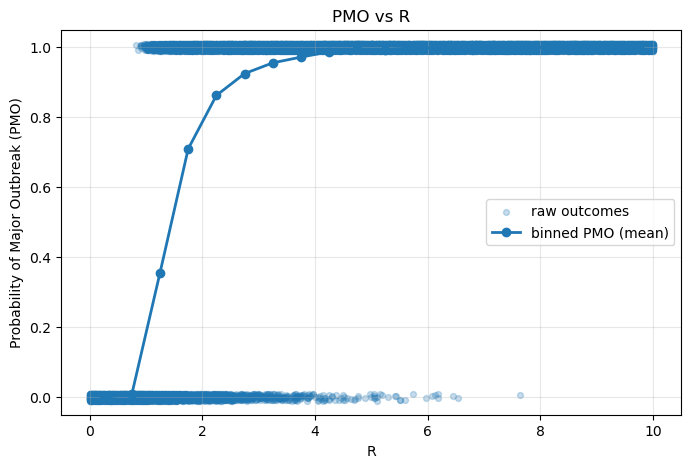

Saved PMO plot to figs/pmo_vs_r.png


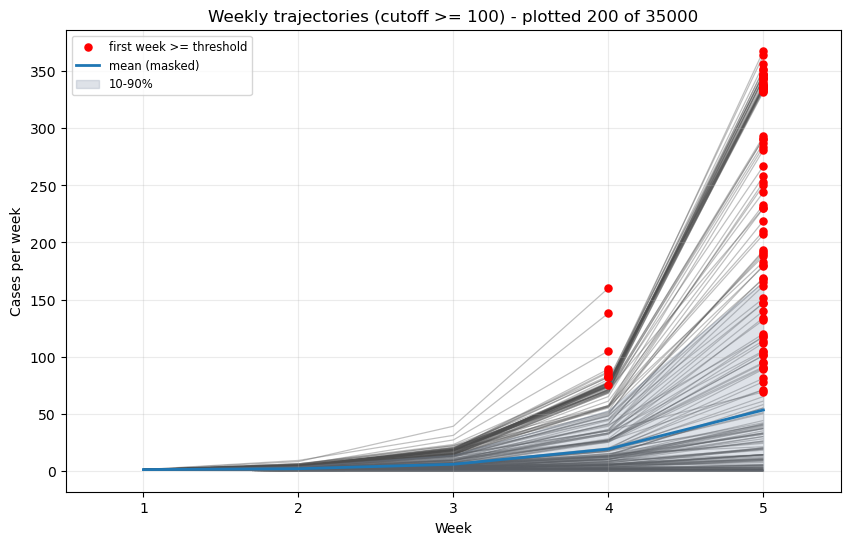

Saved fast trajectories plot to figs/weekly_trajectories.png
Plots written


In [9]:
# ---- equivalent of: runner.py plot ----
run_plotting(
    csv=SIM_OUT,
    sample_strategy="hybrid",
    sample_size=200,
    overlay_mean=True,
    overlay_quantiles=(0.1, 0.9),
    bins=20,
    major_threshold=100,
    random_seed=42,
)
print("Plots written")

## 6. Analytic PMO estimator (`analytic` command)

Given an observed early sequence of weekly counts, integrate the conditional
probability of a major outbreak `PMO(R)` (from branching-process theory) over
the posterior of `R` under a Poisson-renewal likelihood with a uniform prior.

This cell uses an independent, high-precision `quad`-based weekly weight
function (`weekly_w`) exactly as the analytic module does.

*(from `analytic/analytical_refractor.py`)*

In [10]:
def weekly_w(max_weeks=50, mean=MEAN_SI_DAYS, sd=SD_SI_DAYS):
    """High-precision weekly serial weights via scipy.quad (analytic module variant)."""
    shape = (mean / sd) ** 2
    scale = sd ** 2 / mean

    def g(x):
        return scipy_gamma.pdf(x, a=shape, scale=scale)

    w = np.zeros(max_weeks)
    for k in range(1, max_weeks + 1):
        left = max(0.0, 7 * (k - 1))
        right = 7 * (k + 1)

        def integrand(u):
            return (1.0 - abs(u - 7 * k) / 7.0) * g(u) if abs(u - 7 * k) <= 7 else 0.0

        val, _ = quad(integrand, left, right, epsabs=1e-9, epsrel=1e-9)
        w[k - 1] = val

    w[0] = max(0.0, 1.0 - w[1:].sum())
    w /= w.sum()
    return w


def parse_initial_cases(s: str) -> List[int]:
    if not s:
        return []
    toks = [t for t in re.split(r"[,\s;]+", s.strip()) if t]
    return [int(t) for t in toks]


def log_likelihood_I(I_seq: List[int], R: float, w: np.ndarray) -> float:
    """Poisson-renewal log-likelihood of an observed early sequence given R."""
    I = np.asarray(I_seq, dtype=float)
    T = len(I)
    ll = 0.0
    for t in range(1, T):
        max_s = min(t, len(w))
        infectious = sum(I[t - s] * w[s - 1] for s in range(1, max_s + 1))
        lam = R * infectious
        if lam <= 0.0:
            if I[t] == 0:
                continue
            return -np.inf
        ll += I[t] * math.log(lam) - lam - gammaln(int(I[t]) + 1)
    return ll


def extinction_q(R: float) -> float:
    """Probability the branching process dies out, given R."""
    if R <= 1.0:
        return 1.0
    z = -R * math.exp(-R)
    q = -lambertw(z).real / R
    return float(max(0.0, min(1.0, q)))


def PMO_given_R_general(I_seq: List[int], R: float, w: np.ndarray) -> float:
    """PMO conditional on R via the residual-infectiousness extinction probability."""
    I = np.asarray(I_seq, dtype=float)
    T = len(I)
    q = extinction_q(R)

    total = 0.0
    for k in range(1, T + 1):
        m = T - k
        if m <= 0:
            sum_w = 0.0
        else:
            sum_w = float(np.sum(w[:min(m, len(w))]))
        total += I[k - 1] * (1.0 - sum_w)

    log_none = R * (q - 1.0) * total
    if log_none < -700:
        none_prob = 0.0
    elif log_none > 700:
        none_prob = 1.0
    else:
        none_prob = math.exp(log_none)
    none_prob = min(1.0, max(0.0, none_prob))
    return 1.0 - none_prob


def PMO_general(I_seq, w=None, nR=2001, R_min=DEFAULT_R_MIN, R_max=DEFAULT_R_MAX):
    """Integrate PMO(R) over the posterior of R given early counts.

    Returns (PMO_val, R_grid, loglikes, pmogivenR, post)."""
    if w is None:
        w = weekly_w(max_weeks=max(40, len(I_seq) + 5))
    if len(w) < len(I_seq):
        w = weekly_w(max_weeks=len(I_seq) + 10)

    R_grid = np.linspace(R_min, R_max, nR)
    delta = R_grid[1] - R_grid[0]

    loglikes = np.array([log_likelihood_I(I_seq, R, w) for R in R_grid], dtype=float)
    if not np.any(np.isfinite(loglikes)):
        post = np.zeros_like(loglikes)
        pmogivenR = np.zeros_like(loglikes)
        return 0.0, R_grid, loglikes, pmogivenR, post

    logpost = loglikes - logsumexp(loglikes + math.log(delta))
    post = np.exp(logpost)
    pmogivenR = np.array([PMO_given_R_general(I_seq, R, w) for R in R_grid], dtype=float)
    PMO_val = float(np.sum(pmogivenR * post * delta))
    return PMO_val, R_grid, loglikes, pmogivenR, post


def compute_pmo_from_string(initial_cases: str, nR=2001, R_min=DEFAULT_R_MIN, R_max=DEFAULT_R_MAX) -> Dict:
    """High-level helper: parse '1,2,0' and return PMO + diagnostics."""
    I_seq = parse_initial_cases(initial_cases)
    if not I_seq:
        raise ValueError("initial_cases must be a non-empty string of integers")
    PMO_val, R_grid, loglikes, pmogivenR, post = PMO_general(I_seq, nR=nR, R_min=R_min, R_max=R_max)
    return {
        "I_seq": I_seq, "PMO": PMO_val,
        "extinction_prob": max(0.0, min(1.0, 1.0 - PMO_val)),
        "R_grid": R_grid, "loglikes": loglikes, "pmogivenR": pmogivenR, "post": post,
    }

In [11]:
# ---- equivalent of: runner.py analytic --initial-cases 1 ----
ANALYTIC_INITIAL_CASES = "1"
ANALYTIC_R_MIN, ANALYTIC_R_MAX = 0.0, 10.0

res = compute_pmo_from_string(
    initial_cases=ANALYTIC_INITIAL_CASES,
    nR=2001,
    R_min=ANALYTIC_R_MIN,
    R_max=ANALYTIC_R_MAX,
)

print("Observed sequence (weeks 1..T):", res["I_seq"])
print(f"Estimated PMO integrated over R in [{ANALYTIC_R_MIN},{ANALYTIC_R_MAX}] = {res['PMO']:.6f}")
print(f"Estimated extinction probability = {res['extinction_prob']:.6f}")

Observed sequence (weeks 1..T): [1]
Estimated PMO integrated over R in [0.0,10.0] = 0.835343
Estimated extinction probability = 0.164657


Optional: visualise the analytic intermediates — the posterior over `R` and
`PMO(R)`. (Not part of `runner.py`'s text output, but a useful sanity check.)

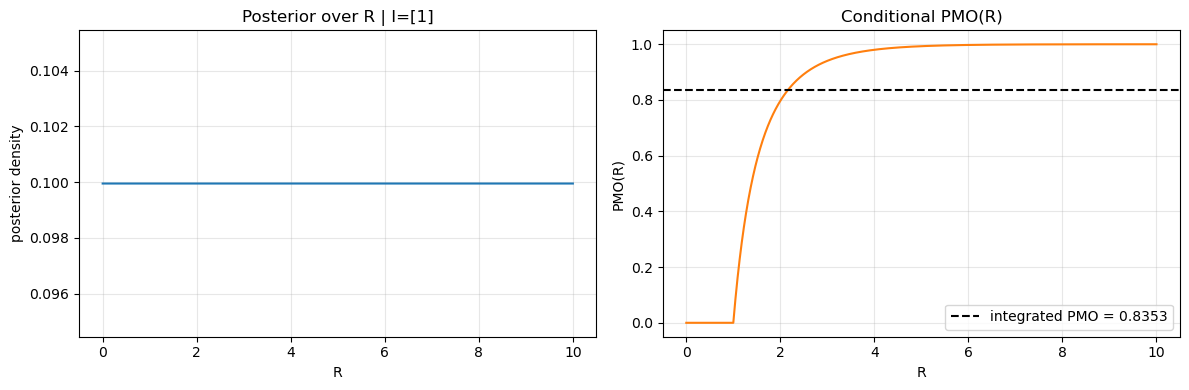

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(res["R_grid"], res["post"], color="tab:blue")
axes[0].set_xlabel("R"); axes[0].set_ylabel("posterior density")
axes[0].set_title(f"Posterior over R | I={res['I_seq']}")
axes[0].grid(alpha=0.3)

axes[1].plot(res["R_grid"], res["pmogivenR"], color="tab:orange")
axes[1].axhline(res["PMO"], ls="--", color="k", label=f"integrated PMO = {res['PMO']:.4f}")
axes[1].set_xlabel("R"); axes[1].set_ylabel("PMO(R)")
axes[1].set_title("Conditional PMO(R)")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Trajectory matching

`trajectory_match_pmo` finds simulated trajectories whose first `len(observed)`
weekly counts exactly equal the observed counts, then computes the empirical PMO
fraction among the matches.

*(from `trajectory_matching/trajectory.py`)*

In [13]:
def trajectory_match_pmo(observed_weeks, simulated_csv, header_rows=3,
                         week_prefix="week_", return_matches_df=False) -> Dict[str, Any]:
    """Match simulated trajectories whose first k weekly counts == observed_weeks."""
    simulated_path = Path(simulated_csv)
    if not simulated_path.exists():
        raise FileNotFoundError(f"Simulated CSV not found: {simulated_csv}")

    df = pd.read_csv(simulated_path, header=header_rows)

    week_cols = [c for c in df.columns if c.startswith(week_prefix)]
    if not week_cols:
        raise ValueError(f"No columns starting with '{week_prefix}' found in {simulated_csv}")
    try:
        week_cols = sorted(week_cols, key=lambda s: int(s.split("_")[1]))
    except Exception:
        week_cols = sorted(week_cols)

    k = len(observed_weeks)
    if k <= 0:
        raise ValueError("observed_weeks must contain at least one value")
    if k > len(week_cols):
        raise ValueError(f"observed_weeks length ({k}) > available simulated weeks ({len(week_cols)})")

    obs_arr = np.asarray(observed_weeks, dtype=int)
    sim_firstk = df[week_cols[:k]].fillna(-999).astype(int).to_numpy()
    matches_mask = np.all(sim_firstk == obs_arr.reshape(1, -1), axis=1)

    matched_indices = list(np.nonzero(matches_mask)[0].tolist())
    n_matches = int(matches_mask.sum())

    n_major = 0
    pmo_fraction: Optional[float] = None
    matches_df = None

    if n_matches > 0:
        if "PMO" not in df.columns:
            raise ValueError("CSV does not contain 'PMO' column; cannot compute PMO fraction.")
        matches_df = df.loc[matches_mask].copy()
        try:
            pmo_vals = matches_df["PMO"].astype(int).to_numpy()
        except Exception:
            pmo_vals = matches_df["PMO"].apply(lambda x: 1 if x else 0).to_numpy()
        n_major = int((pmo_vals == 1).sum())
        pmo_fraction = float(n_major) / float(n_matches)

    out: Dict[str, Any] = {
        "n_matches": n_matches, "n_major": n_major,
        "pmo_fraction": pmo_fraction, "matched_indices": matched_indices,
    }
    if return_matches_df:
        out["matches_df"] = matches_df
    return out

## 8. Matched-trajectory plot (`match` command)

Plots matched trajectories (blue = major / PMO=1, gray = minor), marks the
cutoff week with a red dot, and writes the auxiliary CSVs the source produces.

The cell after runs the equivalent of:

```
python -m outbreak_probabilities.runner match \
    --sim-csv data/test_simulations.csv --initial-cases 1,2,3 \
    --out figs/matched_trajectories.png --sample-strategy highest_peak
```

*(from `trajectory_matching/plot_matches_refractor.py`)*

In [14]:
# module-level styling constants (referenced by the plot title, as in the source)
MATCH_SAMPLE_STRATEGY = "highest_peak"
BLUE = "tab:blue"
GRAY = "dimgray"
ALPHA = 0.6
LINEWIDTH = 1.0


def _match_load_matches(sim_csv, observed, header_rows, week_prefix):
    return trajectory_match_pmo(observed_weeks=observed, simulated_csv=sim_csv,
                                header_rows=header_rows, week_prefix=week_prefix,
                                return_matches_df=True)


def get_week_columns(df, week_prefix):
    week_cols = [c for c in df.columns if c.startswith(week_prefix)]
    return sorted(week_cols, key=lambda s: int(s.split(week_prefix)[1]))


def prepare_plot_data(matches_df, week_cols, max_plot, major_threshold):
    if "PMO" not in matches_df.columns:
        raise SystemExit("Matched dataframe missing 'PMO' column.")
    pmo_flags = matches_df["PMO"].astype(int).to_numpy()
    arr = matches_df[week_cols].to_numpy(dtype=float)
    if max_plot is not None and max_plot < arr.shape[0]:
        arr = arr[:max_plot, :].copy()
        pmo_flags = pmo_flags[:max_plot].copy()
    plotted = arr.shape[0]
    cumul = np.cumsum(arr, axis=1)
    reached = (cumul >= major_threshold).any(axis=1)
    hit_idx = np.argmax(cumul >= major_threshold, axis=1)
    n_weeks = arr.shape[1]
    return arr, pmo_flags, cumul, reached, hit_idx, n_weeks, plotted


def plot_matches(arr, pmo_flags, cumul, reached, hit_idx, n_weeks, plotted,
                 n_matches, n_total, pmo_fraction, major_threshold, observed,
                 out_png, figsize):
    weeks = np.arange(1, n_weeks + 1)
    fig, ax = plt.subplots(figsize=figsize)

    for i, weekly in enumerate(arr):
        color = BLUE if pmo_flags[i] == 1 else GRAY
        if reached[i]:
            k = int(hit_idx[i])
            ax.plot(weeks[: k + 1], weekly[: k + 1], color=color, alpha=ALPHA, linewidth=LINEWIDTH)
        else:
            ax.plot(weeks, weekly, color=color, alpha=ALPHA, linewidth=LINEWIDTH)

    if reached.any():
        xs = weeks[hit_idx[reached]]
        ys = arr[reached, :][np.arange(xs.size), hit_idx[reached]]
        ax.scatter(xs, ys, color="red", s=20, zorder=3, label="cutoff")

    pmo_label = f"PMO (matched) = {pmo_fraction:.3f}" if pmo_fraction is not None else "PMO (matched) = NA"
    ax.plot([], [], color=BLUE, label="PMO = 1 (matched)")
    ax.plot([], [], color=GRAY, label="PMO = 0 (matched)")
    ax.plot([], [], " ", label=f"{pmo_label}")

    ax.set_xlim(1, n_weeks + 0.5)
    ax.set_xticks(np.arange(1, n_weeks + 1, 1))
    ax.minorticks_on()
    ax.xaxis.set_major_locator(MultipleLocator(1))
    ax.xaxis.set_minor_locator(AutoMinorLocator(1))
    plt.tick_params(axis="x", which="minor", bottom=False, top=False, labelbottom=False)

    if reached.any():
        ax.set_ylim(0, max(arr[reached, :].max(), 1) + 1)
    else:
        ax.set_ylim(0, max(arr.max(), 1) + 1)

    ax.set_xlabel("Week"); ax.set_ylabel("Cases per week")
    obs_str = ", ".join(str(x) for x in observed) if observed else "[]"
    ax.set_title(
        f"Matched trajectories (plotted {plotted} out of {n_matches}/{n_total} matches.)\n"
        f"Initial Cases: {obs_str}  |  Cutoff: cumulative >= {major_threshold}\n"
        f"Strategy used: {MATCH_SAMPLE_STRATEGY}")

    ax.legend(frameon=False, fontsize=9, loc="upper left")
    for s in ("top", "right", "bottom", "left"):
        ax.spines[s].set_visible(False)
    plt.gca().get_xaxis().get_major_formatter().set_useOffset(False)
    ax.grid(which="major", color="0.65", linewidth=1.2, alpha=0.6)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.grid(which="minor", color="0.85", linewidth=0.6, alpha=0.8)

    Path(out_png).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=300)
    plt.show()


def run_plot_matches(sim_csv, observed, header_rows=3, week_prefix="week_",
                     major_threshold=100, out_png="figs/matched_trajectories.png",
                     sample_strategy="highest_peak", sample_size=200, max_plot=200,
                     figsize=(9, 6)):
    global MATCH_SAMPLE_STRATEGY
    MATCH_SAMPLE_STRATEGY = sample_strategy

    res = _match_load_matches(sim_csv, observed, header_rows, week_prefix)
    n_matches = res.get("n_matches", 0)
    if n_matches == 0:
        raise SystemExit("No matching trajectories found.")
    pmo_fraction = res.get("pmo_fraction", None)
    matches_df = res.get("matches_df")
    if matches_df is None:
        raise SystemExit("trajectory_match_pmo did not return 'matches_df'.")

    matches_df = matches_df.copy()
    matches_df["match_index"] = matches_df.index.astype(int)

    sim_id_col = "sim_id" if "sim_id" in matches_df.columns else "match_index"
    full_matches_df = matches_df[[sim_id_col, "PMO"]].copy()
    if sim_id_col != "sim_id":
        full_matches_df = full_matches_df.rename(columns={sim_id_col: "sim_id"})

    n_total = len(pd.read_csv(sim_csv, header=header_rows))

    week_cols = get_week_columns(matches_df, week_prefix)
    if not week_cols:
        raise SystemExit("No week_* columns found in matched dataframe.")

    n_matches_total = len(matches_df)
    effective_sample_size = sample_size if sample_size is not None else max_plot
    if effective_sample_size is None or effective_sample_size >= n_matches_total:
        sampled_df = matches_df.copy()
    else:
        sel_idx = np.unique(select_indices(matches_df, week_cols, strategy=sample_strategy,
                                           sample_size=effective_sample_size, random_seed=42))
        sampled_df = matches_df.iloc[sel_idx].reset_index(drop=True)

    arr, pmo_flags, cumul, reached, hit_idx, n_weeks, plotted = prepare_plot_data(
        matches_df=sampled_df, week_cols=week_cols, max_plot=None, major_threshold=major_threshold)

    plot_matches(arr, pmo_flags, cumul, reached, hit_idx, n_weeks, plotted,
                 n_matches=n_matches_total, n_total=n_total, pmo_fraction=pmo_fraction,
                 major_threshold=major_threshold, observed=observed, out_png=out_png, figsize=figsize)

    out_path = Path(out_png)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    stem = out_path.stem
    idx_path = out_path.parent / f"{stem}_match_indices.csv"
    sampled_matches_path = out_path.parent / f"{stem}_sampled_matches.csv"
    full_matches_path = out_path.parent / f"{stem}_matched_trajectories_full.csv"

    pd.DataFrame({"match_index": sampled_df["match_index"].astype(int)}).to_csv(idx_path, index=False)
    sampled_df.to_csv(sampled_matches_path, index=False)
    full_matches_df.to_csv(full_matches_path, index=False)

    print(f"Saved sampled matches dataframe to: {sampled_matches_path}")
    print(f"Saved sampled match indices to: {idx_path}")
    print(f"Saved full matched trajectories (sim_id, PMO) to: {full_matches_path}")
    return out_png, str(sampled_matches_path), str(idx_path), str(full_matches_path)

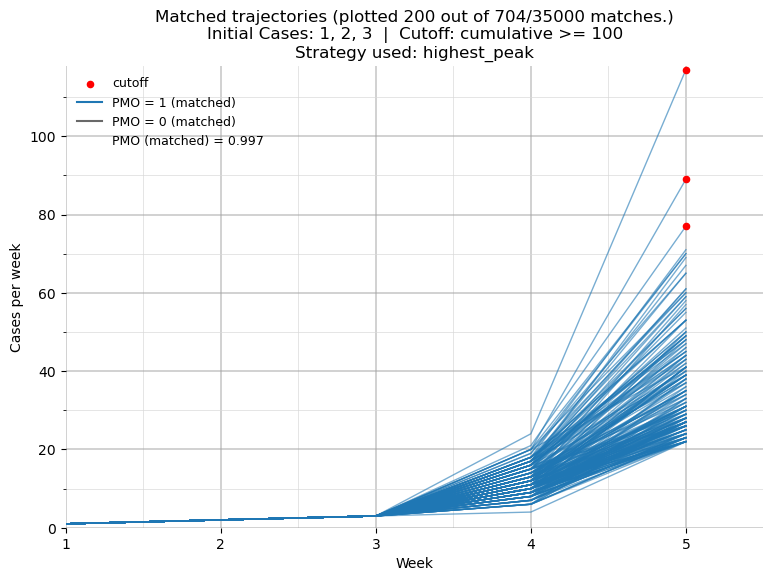

Saved sampled matches dataframe to: figs/matched_trajectories_sampled_matches.csv
Saved sampled match indices to: figs/matched_trajectories_match_indices.csv
Saved full matched trajectories (sim_id, PMO) to: figs/matched_trajectories_matched_trajectories_full.csv
Matched plot -> figs/matched_trajectories.png


In [15]:
# ---- equivalent of: runner.py match ----
match_out = run_plot_matches(
    sim_csv=SIM_OUT,
    observed=[1, 2, 3],
    out_png="figs/matched_trajectories.png",
    sample_size=200,
    max_plot=200,
    major_threshold=100,
    sample_strategy="highest_peak",
)
print("Matched plot ->", match_out[0])

## 9. Cumulative PMO across matched outbreaks (`pmo_vs_r` command)

Running empirical PMO over sampled matched trajectories (`r = 1..R`), with a
random-shuffling confidence band and the analytic PMO overlaid for reference.
The full-index variant (x-axis = full simulation ID range) is also supported.

The cell after runs the equivalent of:

```
python -m outbreak_probabilities.runner pmo_vs_r \
    --sim-csv data/test_simulations.csv --initial-cases 1,2,3 \
    --out figs/pmo_vs_r.png --sample-strategy random
```

*(from `trajectory_matching/plot_pmo_vs_r_refractor.py`)*

In [16]:
def compute_running_ci(pmo_flags, n_boot=1000, ci=0.90, random_seed=None):
    """Pointwise CI band for running PMO via repeated shuffling of pmo_flags."""
    if pmo_flags is None or pmo_flags.size == 0:
        return np.array([]), np.array([])
    R = pmo_flags.size
    rng = np.random.default_rng(random_seed)
    n_boot = max(1, int(n_boot))
    runs = np.empty((n_boot, R), dtype=float)
    for i in range(n_boot):
        perm_flags = pmo_flags[rng.permutation(R)]
        csum = np.cumsum(perm_flags, dtype=float)
        runs[i, :] = csum / np.arange(1, R + 1, dtype=float)
    alpha = 1.0 - float(ci)
    lower = np.percentile(runs, 100.0 * (alpha / 2.0), axis=0)
    upper = np.percentile(runs, 100.0 * (1.0 - alpha / 2.0), axis=0)
    return lower, upper


def prepare_sample(matches_df, week_cols, sample_strategy, sample_size, random_seed=None):
    n_total = len(matches_df)
    if sample_size is None or sample_size >= n_total:
        return matches_df.copy().reset_index(drop=True)
    sel_idx = np.array(select_indices(matches_df, week_cols, strategy=sample_strategy,
                                      sample_size=sample_size, random_seed=random_seed), dtype=int)
    return matches_df.iloc[sel_idx].reset_index(drop=True)


def compute_pmo_r_from_ordered(sampled_df) -> np.ndarray:
    pmo_flags = sampled_df["PMO"].astype(int).to_numpy()
    if pmo_flags.size == 0:
        return np.array([], dtype=float)
    cumsum = np.cumsum(pmo_flags, dtype=float)
    return cumsum / np.arange(1, pmo_flags.size + 1, dtype=float)


def plot_pmo_vs_r(pmo_r, out_png, figsize, observed, sample_strategy, sample_size,
                  sort_by, analytic_pmo=None, pmo_flags=None, show_final_pmo=False,
                  show_ci=True, ci=0.90, n_boot=500, ci_random_seed=42) -> str:
    AZURE = "xkcd:azure"; ORANGE = "xkcd:bright orange"
    LIGHT_POINT_ALPHA = 0.50; LINE_ALPHA = 0.95
    R = int(pmo_r.size)
    rs = np.arange(1, R + 1)

    lower = upper = None
    if show_ci and (pmo_flags is not None) and (pmo_flags.size == R) and R > 0:
        try:
            lower, upper = compute_running_ci(pmo_flags=pmo_flags, n_boot=n_boot, ci=ci,
                                              random_seed=ci_random_seed)
        except Exception:
            lower = upper = None

    fig, ax = plt.subplots(figsize=figsize)
    overall = float(pmo_r[-1]) if R > 0 else float("nan")

    if lower is not None and upper is not None and lower.size == R and upper.size == R:
        ax.fill_between(rs, lower, upper, alpha=0.18, color=AZURE, zorder=1,
                        label=f"{int(ci*100)}% band (random shuffling)")

    if R > 0:
        n_pts = min(50, R)
        idx = np.linspace(0, R - 1, n_pts, dtype=int)
        ax.scatter(rs[idx], pmo_r[idx], s=30, c=[AZURE] * n_pts, edgecolors="none",
                   alpha=LIGHT_POINT_ALPHA, zorder=2, label="_nolegend_")
        ax.plot(rs, pmo_r, linewidth=2.0, alpha=LINE_ALPHA, color=AZURE,
                label=f"Running PMO = {overall:.5f}", zorder=3)

    if analytic_pmo is not None and np.isfinite(analytic_pmo):
        ax.axhline(analytic_pmo, linestyle="--", linewidth=1.4, color=ORANGE, alpha=1.0,
                   label=f"Analytic PMO = {analytic_pmo:.5f}", zorder=5)

    ax.set_xlabel("Sampled matched trajectory index")
    ax.set_ylabel("Cumulative PMO fraction")
    obs_str = ", ".join(str(x) for x in observed) if observed else "[]"
    ax.set_title(f"Cumulative PMO across matched outbreaks\n{R} outbreaks with initial cases {obs_str}\n"
                 f"Sampling: {sample_strategy} | sort_by: {sort_by}")
    ax.set_xlim(1, max(1, R)); ax.set_ylim(-0.01, 1.02)

    if R > 1:
        ticks = np.unique(np.round(np.linspace(1, R, min(10, R))).astype(int))
        ticks[0] = 1; ticks[-1] = R
        ax.set_xticks(ticks)
    else:
        ax.set_xticks([1])

    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25, which="major", linestyle="--")
    ax.legend(frameon=False, fontsize=9, loc="upper right")

    Path(out_png).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()
    return out_png


def plot_pmo_over_full_index(sel_sim_ids, sel_pmo, N_total, out_png, figsize,
                             analytic_single=None, observed=None, sample_strategy="unknown",
                             sort_by="sample_order", n_matches=None, show_ci=True, ci=0.90,
                             n_boot=500, ci_random_seed=42, max_points=5000):
    AZURE = "xkcd:azure"; ORANGE = "xkcd:bright orange"; LINE_ALPHA = 0.95

    if sel_sim_ids.size == 0:
        events_df = pd.DataFrame(columns=["sim_id", "PMO", "event_order", "cum_pmo"])
        dense_x = np.array([1, N_total], dtype=float)
        dense_y = np.zeros_like(dense_x, dtype=float)
        final_pmo = 0.0
        dense_lower = dense_upper = np.zeros_like(dense_x, dtype=float)
    else:
        m = sel_pmo.size
        cum_pmo_fraction = np.cumsum(sel_pmo) / np.arange(1, m + 1)
        events_df = pd.DataFrame({
            "sim_id": sel_sim_ids.astype(int), "PMO": sel_pmo.astype(int),
            "event_order": np.arange(1, m + 1, dtype=int), "cum_pmo": cum_pmo_fraction})
        if N_total <= max_points:
            dense_x = np.arange(1, N_total + 1, dtype=float)
        else:
            dense_x = np.linspace(1.0, float(N_total), num=max_points, dtype=float)
        final_pmo = float(cum_pmo_fraction[-1])
        event_x = sel_sim_ids.astype(float)
        event_y = cum_pmo_fraction.astype(float)
        dense_y = np.interp(dense_x, event_x, event_y, left=0.0, right=final_pmo)

        dense_lower = dense_upper = None
        if show_ci and m > 0:
            try:
                lower_evt, upper_evt = compute_running_ci(pmo_flags=sel_pmo.astype(int),
                                                          n_boot=n_boot, ci=ci, random_seed=ci_random_seed)
                dense_lower = np.interp(dense_x, event_x, lower_evt, left=0.0, right=final_pmo)
                dense_upper = np.interp(dense_x, event_x, upper_evt, left=0.0, right=final_pmo)
            except Exception:
                dense_lower = dense_upper = None

    fig, ax = plt.subplots(figsize=figsize)
    if (dense_lower is not None) and (dense_upper is not None):
        ax.fill_between(dense_x, dense_lower, dense_upper, alpha=0.18, color=AZURE, zorder=1,
                        label=f"{int(ci*100)}% band (random shuffling)")

    ax.plot(dense_x, dense_y, linewidth=2.0, alpha=LINE_ALPHA, color=AZURE,
            label=f"Running PMO = {final_pmo:.5f}", zorder=2)

    if analytic_single is not None and np.isfinite(analytic_single):
        ax.axhline(analytic_single, linestyle="--", linewidth=1.5, color=ORANGE, alpha=1.0,
                   label=f"Analytic PMO = {analytic_single:.3f}", zorder=5)

    ax.set_xlim(1, float(N_total) + 0.5); ax.set_ylim(-0.01, 1.05)
    ax.set_xlabel("Simulation ID (1..N_total)"); ax.set_ylabel("Cumulative PMO fraction")
    obs_str = ", ".join(str(x) for x in (observed or [])) if observed is not None else "[]"
    n_matches_local = int(n_matches) if (n_matches is not None) else int(sel_sim_ids.size)
    ax.set_title(f"Cumulative PMO across matched outbreaks over full simulation\n"
                 f"{n_matches_local} outbreaks with initial cases {obs_str}\n")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25, which="major", linestyle="--")
    ax.legend(frameon=False, fontsize=9, loc="upper right")

    out_png_full = Path(out_png).with_name(Path(out_png).stem + "_full_index.png")
    Path(out_png_full).parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_png_full, dpi=300, bbox_inches="tight")
    plt.show()
    return str(out_png_full), events_df


def run_pmo_vs_r_refractor(sim_csv, observed, header_rows=3, week_prefix="week_",
                           out_png="figs/pmo_vs_r.png", sample_strategy="random",
                           sample_size=200, sort_by="sample_order", figsize=(8, 5),
                           random_seed=42, full_index=False, show_final_pmo=False,
                           show_ci=True, ci=0.90, n_boot=500, ci_random_seed=42,
                           max_plot=None):
    res = trajectory_match_pmo(observed_weeks=observed, simulated_csv=sim_csv,
                               header_rows=header_rows, week_prefix=week_prefix,
                               return_matches_df=True)
    n_matches = int(res.get("n_matches", 0))
    if n_matches == 0:
        raise SystemExit("No matching trajectories found.")
    matches_df = res.get("matches_df")
    if matches_df is None:
        raise SystemExit("trajectory_match_pmo did not return 'matches_df'.")

    week_cols = get_week_columns(matches_df, week_prefix)
    if not week_cols:
        raise SystemExit("No week_* columns found in matched dataframe.")

    matches_df = matches_df.copy()
    if "match_index" not in matches_df.columns:
        matches_df["match_index"] = matches_df.index.astype(int)

    sim_id_col = "sim_id" if "sim_id" in matches_df.columns else "match_index"
    full_matches_df = matches_df[[sim_id_col, "PMO"]].copy()
    if sim_id_col != "sim_id":
        full_matches_df = full_matches_df.rename(columns={sim_id_col: "sim_id"})

    out_path_tmp = Path(out_png)
    out_path_tmp.parent.mkdir(parents=True, exist_ok=True)
    full_matches_path = out_path_tmp.parent / f"{out_path_tmp.stem}_matched_trajectories_full.csv"
    full_matches_df.to_csv(full_matches_path, index=False)
    print(f"Saved full matched trajectories (sim_id, PMO) to: {full_matches_path}")

    sampled_df = prepare_sample(matches_df=matches_df, week_cols=week_cols,
                                sample_strategy=sample_strategy, sample_size=sample_size,
                                random_seed=random_seed)

    if max_plot is not None and max_plot < len(sampled_df):
        sampled_df = sampled_df.iloc[:max_plot].reset_index(drop=True)

    if sort_by != "sample_order":
        if sort_by == "by_cumulative":
            key = sampled_df[week_cols].sum(axis=1)
        elif sort_by == "by_peak":
            key = sampled_df[week_cols].max(axis=1)
        elif sort_by == "by_R" and "R_draw" in sampled_df.columns:
            key = sampled_df["R_draw"]
        elif sort_by == "by_PMO":
            key = sampled_df["PMO"].astype(int)
        else:
            key = None
        if key is not None:
            sampled_df = (sampled_df.assign(_key=key).sort_values("_key", ascending=False)
                                    .drop(columns=["_key"]).reset_index(drop=True))
        else:
            sampled_df = sampled_df.reset_index(drop=True)
    else:
        sampled_df = sampled_df.reset_index(drop=True)

    total_df = pd.read_csv(sim_csv, header=header_rows)
    r_col_candidates = [c for c in ("R_draw", "R", "r_draw", "r") if c in total_df.columns]
    if r_col_candidates:
        r_col = r_col_candidates[0]
        try:
            R_min_val = float(total_df[r_col].min()); R_max_val = float(total_df[r_col].max())
            if not np.isfinite(R_min_val):
                R_min_val = DEFAULT_R_MIN
            if not np.isfinite(R_max_val):
                R_max_val = DEFAULT_R_MAX
            if R_min_val > R_max_val:
                R_min_val, R_max_val = R_max_val, R_min_val
        except Exception:
            R_min_val, R_max_val = DEFAULT_R_MIN, DEFAULT_R_MAX
    else:
        R_min_val, R_max_val = DEFAULT_R_MIN, DEFAULT_R_MAX

    initial_cases_str = ",".join(str(int(x)) for x in observed) if observed else ""
    try:
        analytic_pmo = float(compute_pmo_from_string(initial_cases_str, nR=2001,
                                                     R_min=R_min_val, R_max=R_max_val).get("PMO", float("nan")))
    except Exception:
        analytic_pmo = float("nan")

    if not full_index:
        pmo_r = compute_pmo_r_from_ordered(sampled_df)
        pmo_flags = sampled_df["PMO"].astype(int).to_numpy()
        out_path = plot_pmo_vs_r(pmo_r=pmo_r, out_png=out_png, figsize=figsize, observed=observed,
                                 sample_strategy=sample_strategy, sample_size=sample_size, sort_by=sort_by,
                                 analytic_pmo=analytic_pmo, pmo_flags=pmo_flags,
                                 show_final_pmo=show_final_pmo, show_ci=show_ci, ci=ci,
                                 n_boot=n_boot, ci_random_seed=ci_random_seed)
        return out_path, None

    N_total = len(total_df)
    sim_ids_one_based = sampled_df["match_index"].astype(int).to_numpy() + 1
    order_by_simid = np.argsort(sim_ids_one_based)
    sel_sim_ids = sim_ids_one_based[order_by_simid]
    sel_pmo = sampled_df["PMO"].astype(int).to_numpy()[order_by_simid]

    out_path, events_df = plot_pmo_over_full_index(
        sel_sim_ids=sel_sim_ids, sel_pmo=sel_pmo, N_total=N_total, out_png=out_png,
        figsize=figsize, analytic_single=analytic_pmo, observed=observed,
        sample_strategy=sample_strategy, sort_by=sort_by, n_matches=sel_sim_ids.size,
        show_ci=show_ci, ci=ci, n_boot=n_boot, ci_random_seed=ci_random_seed)

    events_csv = Path(out_path).with_name(Path(out_path).stem + "_events.csv")
    events_df.to_csv(events_csv, index=False)
    print(f"Saved events CSV to: {events_csv}")
    return out_path, events_df

Saved full matched trajectories (sim_id, PMO) to: figs/pmo_vs_r_matched_trajectories_full.csv


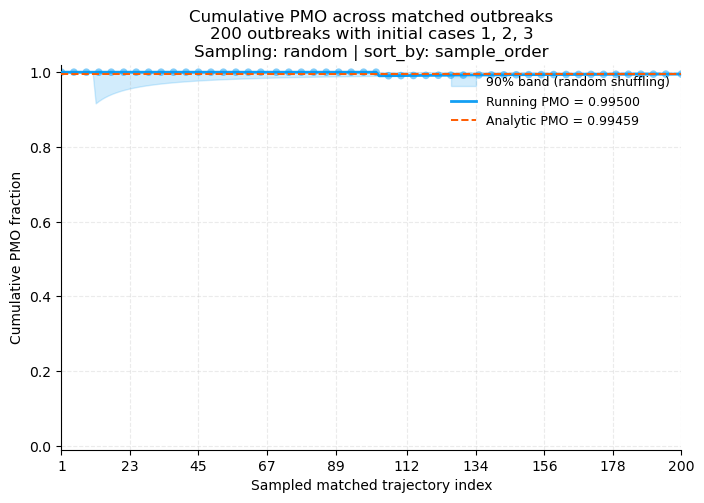

PMO vs r plot -> figs/pmo_vs_r.png


In [17]:
# ---- equivalent of: runner.py pmo_vs_r (sampled-index mode) ----
pmo_out, _ = run_pmo_vs_r_refractor(
    sim_csv=SIM_OUT,
    observed=[1, 2, 3],
    out_png="figs/pmo_vs_r.png",
    sample_strategy="random",
    sample_size=200,
    sort_by="sample_order",
    random_seed=42,
    full_index=False,
    show_ci=True,
    ci=0.9,
)
print(f"PMO vs r plot -> {pmo_out}")

Saved full matched trajectories (sim_id, PMO) to: figs/pmo_vs_r_matched_trajectories_full.csv


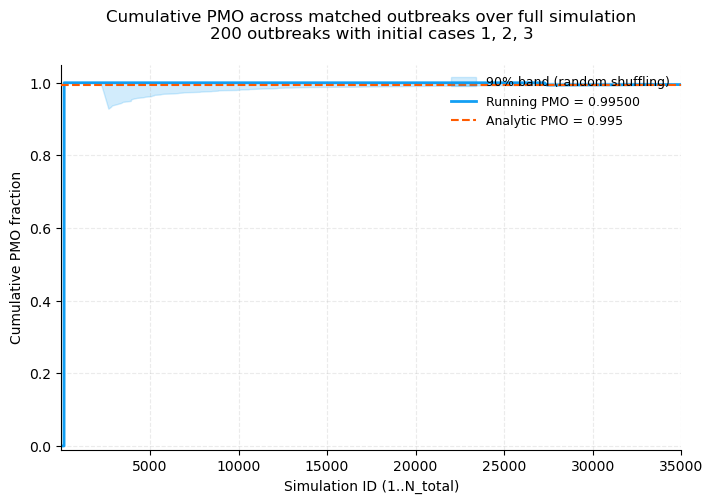

Saved events CSV to: figs/pmo_vs_r_full_index_events.csv
PMO vs r (full index) plot -> figs/pmo_vs_r_full_index.png


,sim_id,PMO,event_order,cum_pmo
0,154,1,1,1.0
1,632,1,2,1.0
2,735,1,3,1.0
3,814,1,4,1.0
4,843,1,5,1.0


In [18]:
# ---- full-index variant: runner.py pmo_vs_r --full-index ----
pmo_full_out, events_df = run_pmo_vs_r_refractor(
    sim_csv=SIM_OUT,
    observed=[1, 2, 3],
    out_png="figs/pmo_vs_r.png",
    sample_strategy="random",
    sample_size=200,
    random_seed=42,
    full_index=True,
    show_ci=True,
    ci=0.9,
)
print(f"PMO vs r (full index) plot -> {pmo_full_out}")
events_df.head()

## 10. Machine-learning PMO estimator

The ML approach learns `PMO` directly from the first three weekly counts
(`week_1, week_2, week_3`). Two classifiers are trained on **increasing data
sizes** (500 → 34,500 samples) so we can watch their predicted outbreak
probability **converge to the analytic solution** for a handful of reference
samples.

- **Training:** `ML_different_data_sizes.py` — fits `RandomForestClassifier`
  and `GradientBoostingClassifier` on growing subsets and saves each
  `(model, scaler, meta)` to `Model_SIM/`.
- **Convergence plots:** `PLot_GBRF_different_data_sizes.py` (GB + RF from
  `Model_SIM`, with a ±5% analytic band) and
  `Plot_ML_different_data_sizes.py` (the older `Model_ML_different_data_sizes`
  set, which on disk contains **RF only**).

> The reference analytic values below are hard-coded in the source scripts.
> They correspond to the §6 estimator evaluated at each sample.

In [19]:
import warnings
import joblib
from datetime import datetime
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler

# paths (relative to the repo root, matching the source scripts' BASE_DIR layout)
ML_DIR = Path("src/outbreak_probabilities/machine_learning")
MODEL_SIM_DIR = ML_DIR / "Model_SIM"
MODEL_ML_DIFF_DIR = ML_DIR / "Model_ML_different_data_sizes"

# analytic reference values per sample (hard-coded in the source plot scripts)
sample_solutions = {
    (1, 2, 0): 0.71617,
    (1, 1, 0): 0.53455,
    (1, 0, 0): 0.22406,
    (1, 2, 1): 0.90805,
    (1, 3, 1): 0.94251,
    (1, 0, 1): 0.74969,
    (1, 5, 3): 0.99822,  # first appears at sample 21441
}

# training-data sizes: 500, 1000, ..., 34500
data_sizes = [500 * i for i in range(1, 70)]
print("ML samples:", list(sample_solutions.keys()))
print("data_sizes:", data_sizes[0], "...", data_sizes[-1], f"({len(data_sizes)} sizes)")

ML samples: [(1, 2, 0), (1, 1, 0), (1, 0, 0), (1, 2, 1), (1, 3, 1), (1, 0, 1), (1, 5, 3)]
data_sizes: 500 ... 34500 (69 sizes)


### 10a. Training (`ML_different_data_sizes.py`)

Faithful reproduction of the training script as a function. It is **guarded by
`RETRAIN`** (default `False`) because:

1. The pre-trained models already ship in `Model_SIM/`, and
2. Retraining the full 0–34,500 sweep is slow **and** only meaningful with a
   large simulation CSV — the §4 default (`N=1000`) is far smaller than the top
   data sizes, so every subset ≥ 1000 would reuse the same 1000 rows.

To genuinely retrain, regenerate a large CSV in §4 (e.g. `N=40000`), then set
`RETRAIN = True`.

In [20]:
def train_ml_models(data_path=SIM_OUT, model_dir=MODEL_SIM_DIR, data_sizes=data_sizes):
    """Train RF + GB on growing subsets of week_1..3 -> PMO and save each model."""
    model_dir.mkdir(parents=True, exist_ok=True)
    (model_dir / "plots").mkdir(parents=True, exist_ok=True)

    # the source reads the raw CSV then strips the 3 metadata rows by hand;
    # header=3 is the equivalent, robust form.
    data = pd.read_csv(data_path, header=3)
    data = data[["week_1", "week_2", "week_3", "PMO"]]
    X = data[["week_1", "week_2", "week_3"]].astype(float)
    y = data["PMO"].astype(int)

    models = {
        "RF": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
        "GB": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    }

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    feature_names = list(X.columns)
    n_weeks = len(feature_names)

    results = {}
    for size in data_sizes:
        X_subset = X_scaled[:size]
        y_subset = y[:size]
        results[size] = {}
        for model_name, model in models.items():
            model.fit(X_subset, y_subset)
            stem = f"ML_SIM_{size}_{model_name}"
            joblib.dump(model, model_dir / f"{stem}.pkl", compress=3)
            joblib.dump(scaler, model_dir / f"{stem}_scaler.pkl", compress=3)
            meta = {
                "model_name": model_name, "n_weeks": n_weeks,
                "feature_names": feature_names, "data_size": size,
                "training_date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
            }
            with open(model_dir / f"{stem}.json", "w") as f:
                json.dump(meta, f, indent=4)
            joblib.dump(meta, model_dir / f"{stem}_meta.pkl", compress=3)
            results[size][model_name] = {
                "model_path": str(model_dir / f"{stem}.pkl"),
                "scaler_path": str(model_dir / f"{stem}_scaler.pkl"),
            }
    with open(model_dir / "training_results.json", "w") as f:
        json.dump(results, f, indent=4)
    print("All models trained and saved to", model_dir)
    return results


RETRAIN = False  # set True only with a large simulation CSV (see note above)
if RETRAIN:
    train_ml_models()
else:
    print("Skipping training; using pre-trained models in", MODEL_SIM_DIR)

Skipping training; using pre-trained models in src/outbreak_probabilities/machine_learning/Model_SIM


### 10b. Prediction helper

`predict_pmo` loads one saved `(model, scaler)` for a given size/model and
returns the predicted probability and label.

*(from `ML_different_data_sizes.py`)*

In [21]:
def predict_pmo(model_name, week_1, week_2, week_3, size=data_sizes[-1],
                model_dir=MODEL_SIM_DIR, threshold=0.5):
    """Predict PMO for one (week_1, week_2, week_3) using a saved model."""
    stem = f"ML_SIM_{size}_{model_name}"
    clf = joblib.load(model_dir / f"{stem}.pkl")
    scaler = joblib.load(model_dir / f"{stem}_scaler.pkl")
    X_input = np.array([[week_1, week_2, week_3]], dtype=float)
    proba = float(clf.predict_proba(scaler.transform(X_input))[0][1])
    pred = int(proba >= threshold)
    return {"model": model_name, "probability": proba, "PMO": pred,
            "predicted_label": "major" if pred == 1 else "minor"}


# quick demo on the largest model
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    print("GB on (1,2,0):", predict_pmo("GB", 1, 2, 0))
    print("RF on (1,2,0):", predict_pmo("RF", 1, 2, 0))

GB on (1,2,0): {'model': 'GB', 'probability': 0.722504220654845, 'PMO': 1, 'predicted_label': 'major'}
RF on (1,2,0): {'model': 'RF', 'probability': 0.7211994945715813, 'PMO': 1, 'predicted_label': 'major'}


### 10c. Convergence plots

`ml_convergence_predictions` loads every saved `(model, scaler)` across data
sizes and predicts each reference sample. Model types whose files are missing
in a directory are skipped (so the RF-only `Model_ML_different_data_sizes` set
still works). Plots display inline and are saved under each directory's
`ML_CONVERGENCE_PLOTS/`, as in the source.

In [22]:
def ml_convergence_predictions(model_dir, data_sizes, samples, model_names=("GB", "RF")):
    """Load models across sizes and predict each sample. Returns
    {sample: {model_name: [probs over data_sizes]}}. Missing model types are skipped."""
    available = []
    for m in model_names:
        if (model_dir / f"ML_SIM_{data_sizes[0]}_{m}.pkl").exists():
            available.append(m)
        else:
            print(f"[skip] no '{m}' models found in {model_dir.name}")
    results = {s: {m: [] for m in available} for s in samples}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # silence StandardScaler feature-name warnings
        for m in available:
            for size in data_sizes:
                stem = f"ML_SIM_{size}_{m}"
                model = joblib.load(model_dir / f"{stem}.pkl")
                scaler = joblib.load(model_dir / f"{stem}_scaler.pkl")
                for s in samples:
                    arr = np.array(s).reshape(1, -1)
                    results[s][m].append(float(model.predict_proba(scaler.transform(arr))[0][1]))
    return results


_GB_COLOR, _RF_COLOR = "darkorange", "royalblue"


def plot_ml_convergence(results, data_sizes, sample_solutions, save_dir,
                        band=0.05, linewidth=3, markers=False, title_prefix="Convergence of ML Models"):
    """Plot predicted PMO vs training-data size with the analytic reference line."""
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)
    for sample in sample_solutions:
        plt.figure(figsize=(10, 6))
        if results[sample].get("GB"):
            plt.plot(data_sizes, results[sample]["GB"], label="GB Predictions",
                     color=_GB_COLOR, linewidth=linewidth, marker="s" if markers else None)
        if results[sample].get("RF"):
            plt.plot(data_sizes, results[sample]["RF"], label="RF Predictions",
                     color=_RF_COLOR, linewidth=linewidth, marker="o" if markers else None)
        sol = sample_solutions[sample]
        plt.axhline(y=sol, color="red", linestyle="--", linewidth=linewidth,
                    label=f"Analytical Solution = {sol}")
        if band:
            plt.fill_between(data_sizes, sol - band, sol + band, color="red", alpha=0.1,
                             label=f"Analytical Solution +/-{int(band*100)}%")
        plt.title(f"{title_prefix} for Sample {sample}")
        plt.xlabel("Training Data Size"); plt.ylabel("Predicted Outbreak Probability")
        plt.ylim(0, 1.13); plt.legend()
        plt.grid(color="lightgrey", linestyle="--", linewidth=0.3)
        out = save_dir / f"Convergence_Sample_{sample[0]}_{sample[1]}_{sample[2]}.png"
        plt.savefig(out)
        plt.show()

#### Canonical convergence: GB + RF from `Model_SIM`

Equivalent of `PLot_GBRF_different_data_sizes.py`.

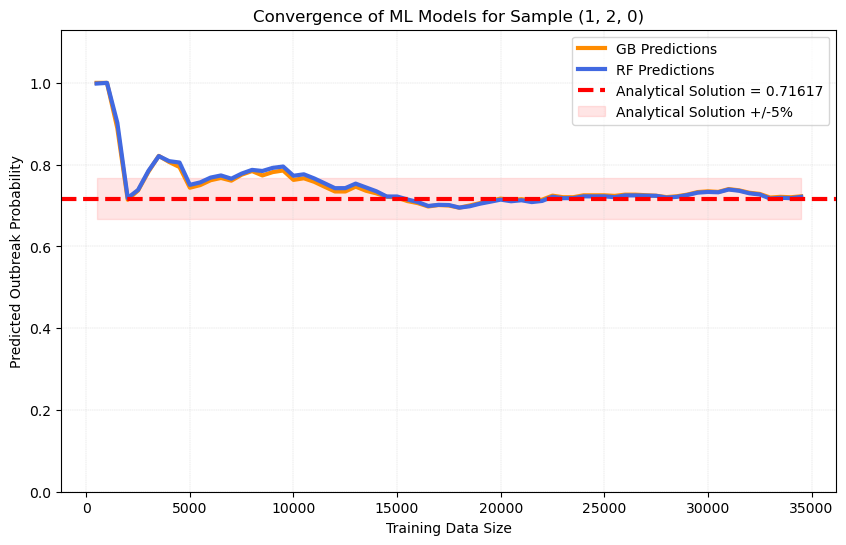

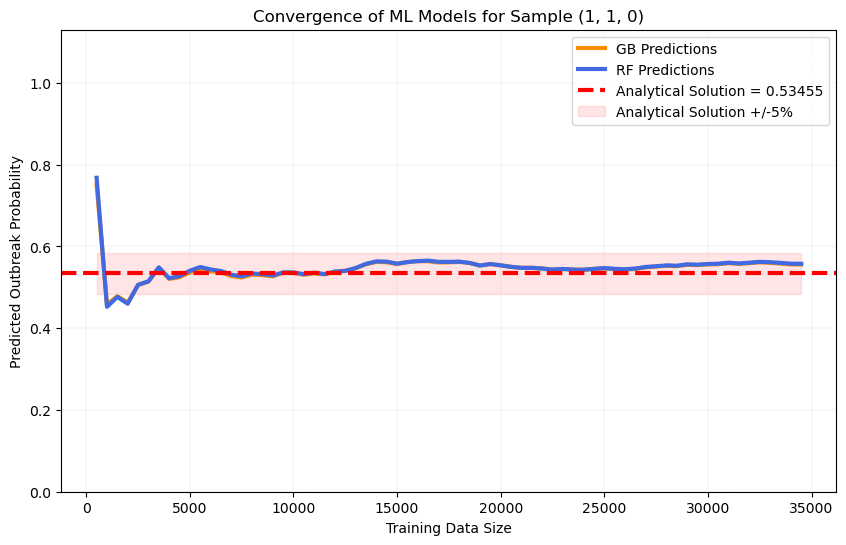

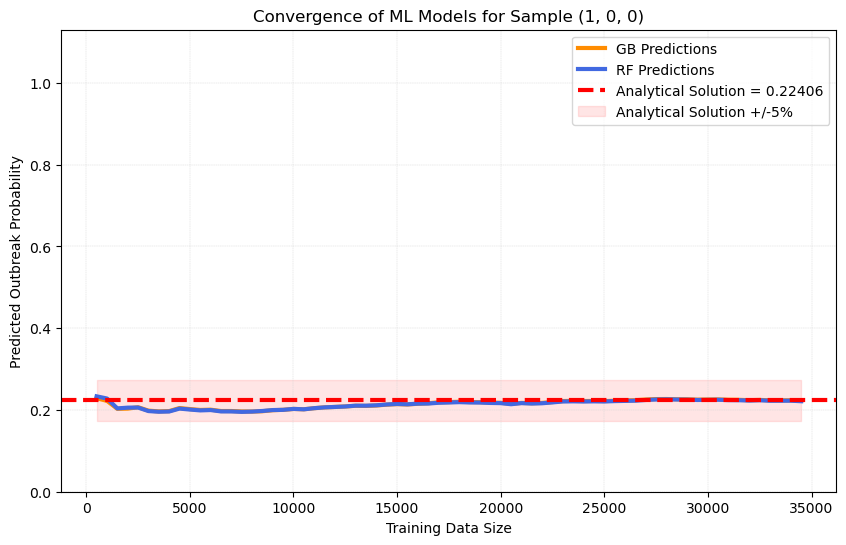

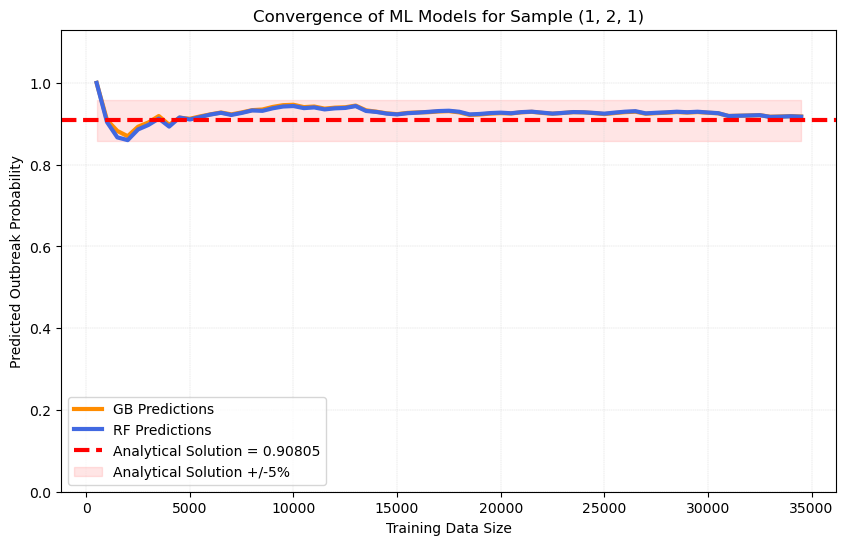

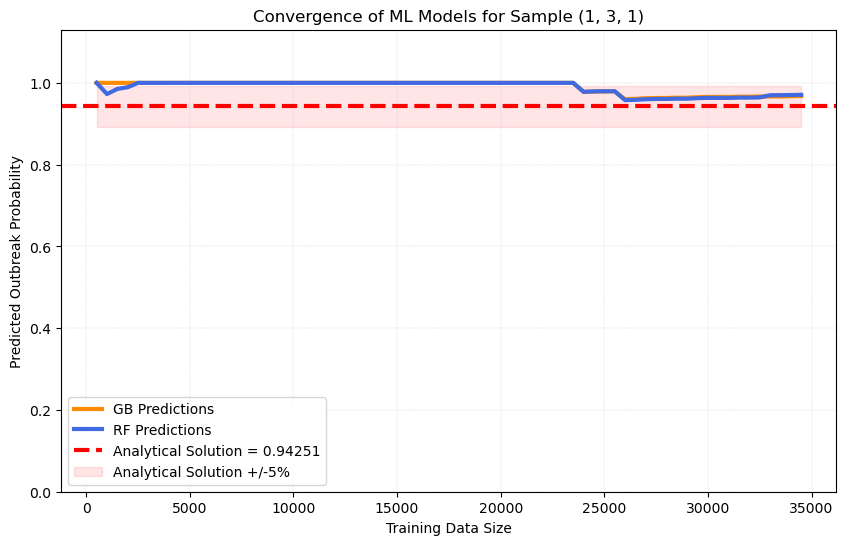

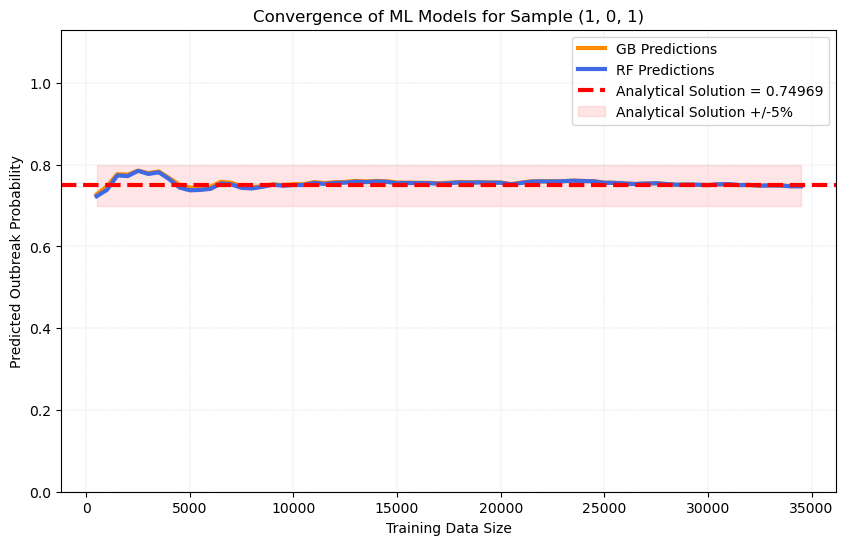

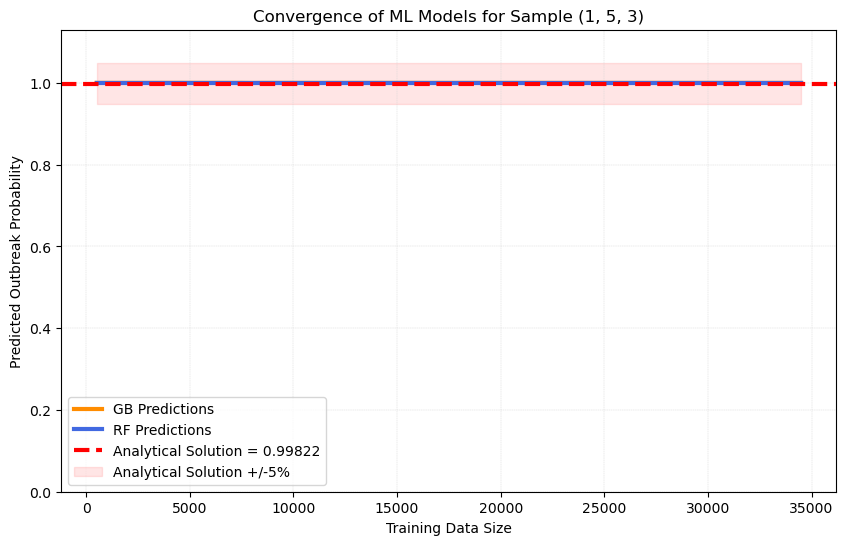

In [23]:
sim_results = ml_convergence_predictions(
    model_dir=MODEL_SIM_DIR, data_sizes=data_sizes, samples=list(sample_solutions.keys()))

plot_ml_convergence(
    sim_results, data_sizes, sample_solutions,
    save_dir=MODEL_SIM_DIR / "ML_CONVERGENCE_PLOTS",
    band=0.05, linewidth=3, markers=False,
    title_prefix="Convergence of ML Models")

#### Older RF-only set: `Model_ML_different_data_sizes`

Equivalent of `Plot_ML_different_data_sizes.py`. That directory ships **RF
models only**, so GB is skipped automatically (the original script assumed both
and would error on the missing GB files).

[skip] no 'GB' models found in Model_ML_different_data_sizes


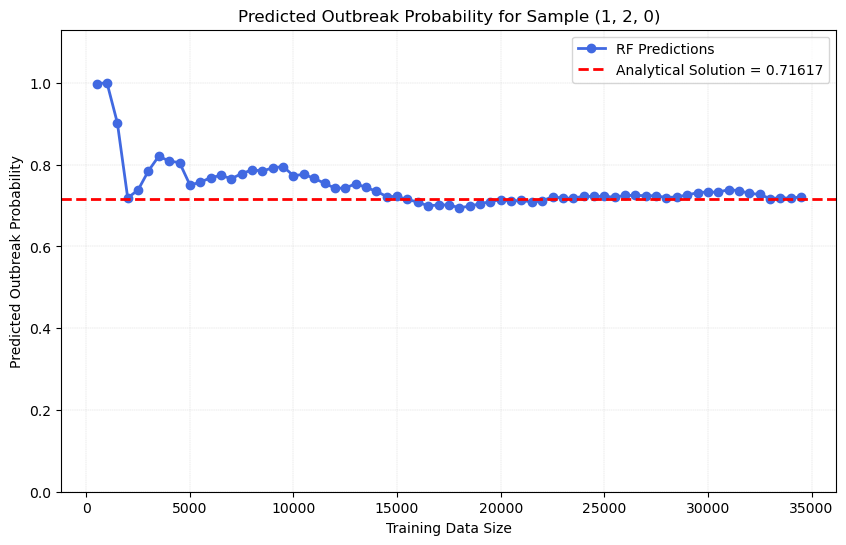

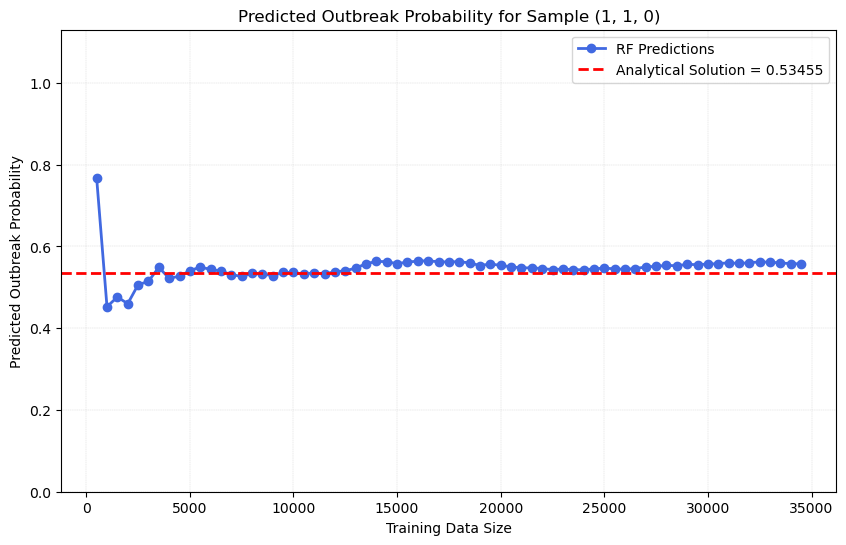

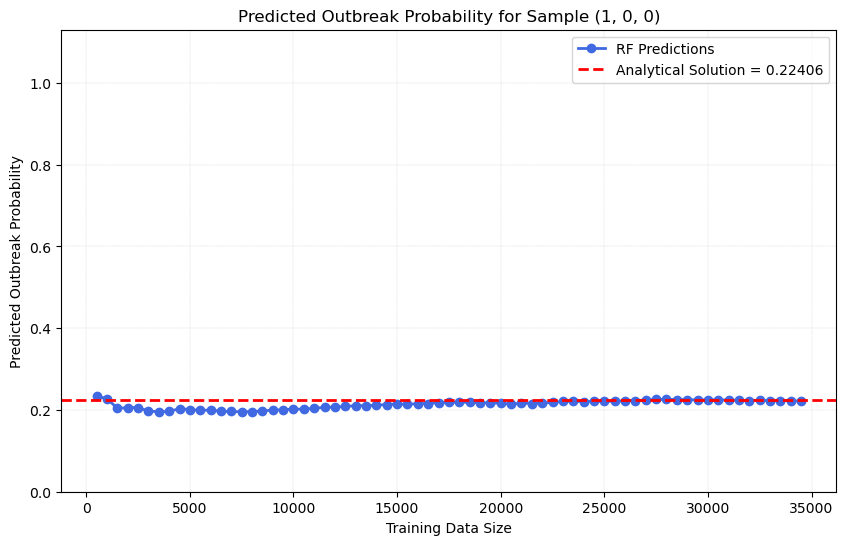

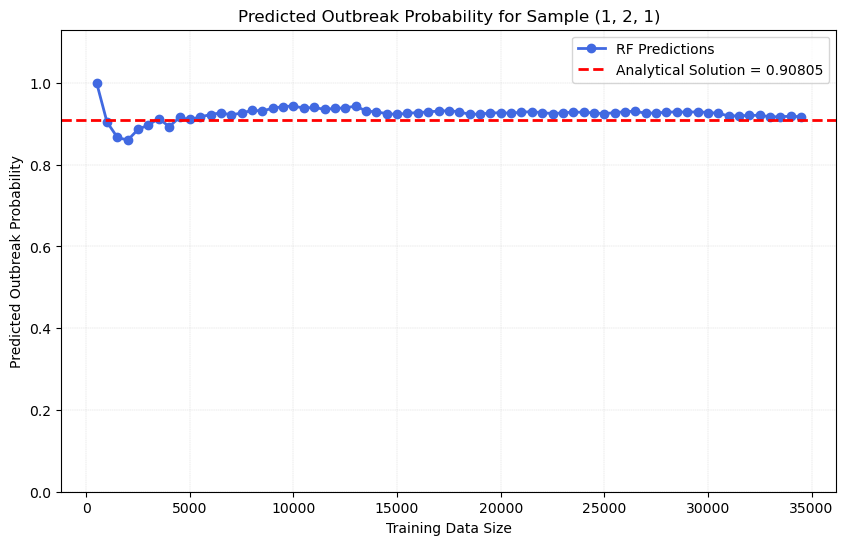

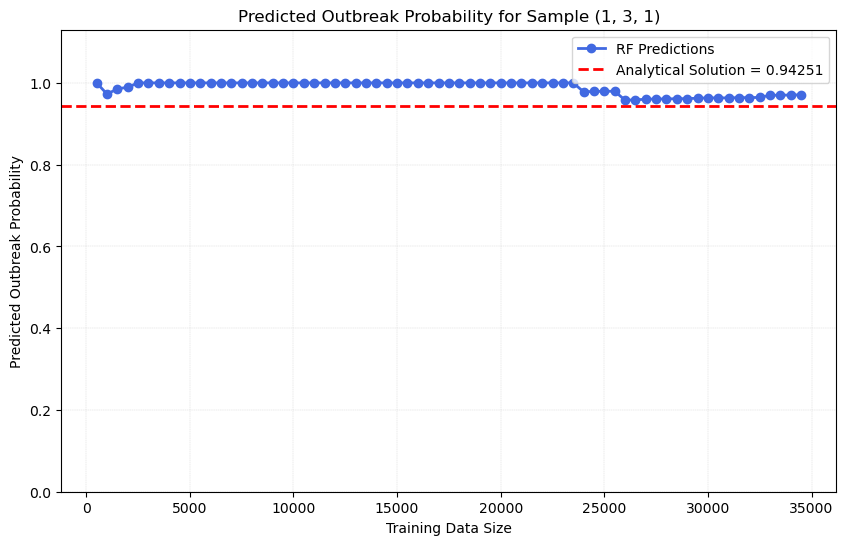

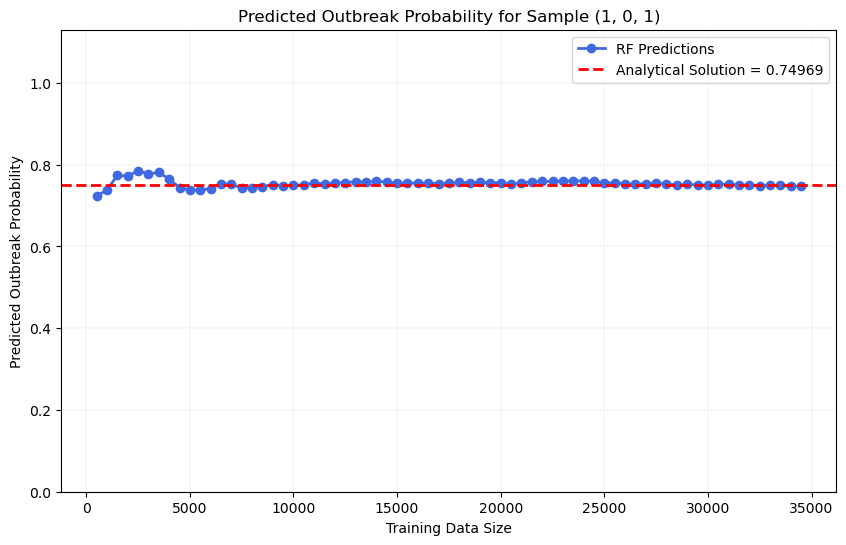

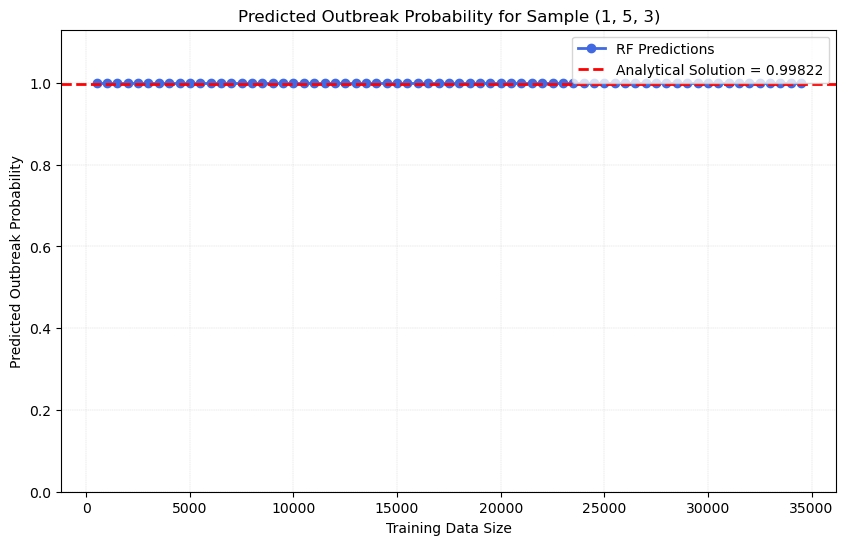

In [24]:
ml_diff_results = ml_convergence_predictions(
    model_dir=MODEL_ML_DIFF_DIR, data_sizes=data_sizes, samples=list(sample_solutions.keys()))

plot_ml_convergence(
    ml_diff_results, data_sizes, sample_solutions,
    save_dir=MODEL_ML_DIFF_DIR / "ML_CONVERGENCE_PLOTS",
    band=None, linewidth=2, markers=True,
    title_prefix="Predicted Outbreak Probability")

## 11. Comparison: ML vs trajectory-matching vs analytic

`compare_combined.py` puts all three estimators of PMO on a single axis for a
given `initial_sample`:

- **ML (GB & RF):** predicted PMO vs training-data size (from `Model_SIM`).
- **Analytic:** horizontal reference line (§6 estimator) with a ±5% band.
- **Trajectory-matching:** computed *only* from rows of the full sim CSV whose
  first `k` weeks exactly match `initial_sample`, shown as a running cumulative
  PMO **step curve mapped onto the ML training-size x-axis** (sim IDs
  `1..max_size` → `min_size..max_size`).

The x-axis is the number of simulations (log scale), so all three methods can be
read against "how much data was used". This reuses the already-defined
`compute_pmo_from_string` (§6) and `compute_running_ci` (§9).

> The comparison is most meaningful when the sim CSV is large; §4 now generates
> 35,000 rows, matching the ML training range.

In [25]:
# compare-specific config (mirrors compare_combined.py defaults)
COMPARE_OUT_DIR = Path("src/outbreak_probabilities/compare")
COMPARE_OUT_DIR.mkdir(parents=True, exist_ok=True)

COL_GB = "xkcd:asparagus"
COL_RF = "royalblue"
COL_PMO = "xkcd:darkblue"
COL_ANALYTIC = "red"
CI_LEVEL = 0.90
CI_BOOT = 500

# in-process cache of matched sim ids per initial sample
matched_index_cache: Dict[Tuple[int, ...], Any] = {}


def load_full_sim_csv(path: str) -> pd.DataFrame:
    """Robustly load the full sim CSV (try header=3, then header=0)."""
    last_exc = None
    for header in (3, 0):
        try:
            df = pd.read_csv(path, header=header)
            df.columns = [str(c).strip() for c in df.columns]
            return df
        except Exception as e:
            last_exc = e
    raise last_exc


def find_matches_in_full_sim_df(full_df, initial_sample, week_prefix="week_") -> pd.DataFrame:
    """Exact-match the first k weeks of full_df to initial_sample."""
    week_cols = get_week_columns(full_df, week_prefix)
    k = len(initial_sample)
    if k == 0:
        raise ValueError("initial_sample empty")
    if k > len(week_cols):
        raise ValueError(f"initial_sample length {k} > available week columns {len(week_cols)}")
    mask = np.ones(len(full_df), dtype=bool)
    for j in range(k):
        col = week_cols[j]
        col_num = pd.to_numeric(full_df[col], errors="coerce").to_numpy()
        mask &= np.isfinite(col_num) & np.isclose(col_num, float(initial_sample[j]), atol=1e-9)
    return full_df.loc[mask].copy().reset_index(drop=True)


def derive_pmo_column(df) -> pd.DataFrame:
    """Ensure a 0/1 PMO column exists, with sensible fallbacks."""
    df = df.copy()
    if "PMO" in df.columns:
        try:
            df["PMO"] = df["PMO"].astype(int)
        except Exception:
            df["PMO"] = df["PMO"].map(
                lambda v: 1 if str(v).strip() in ("1", "True", "true", "major") else 0).astype(int)
        return df
    if "status" in df.columns:
        df["PMO"] = df["status"].astype(str).str.contains("major", case=False, na=False).astype(int)
        return df
    for col in ("final_size", "cumulative_cases"):
        if col in df.columns:
            df["PMO"] = (pd.to_numeric(df[col], errors="coerce").fillna(0) > 0).astype(int)
            return df
    raise RuntimeError("Could not derive PMO column from full sim CSV.")


def load_ml_curves_for_sample(sample_tuple, model_dir, data_sizes, model_names) -> Dict[str, List]:
    """Predicted PMO across data sizes for each ML model (None where a model is missing)."""
    results = {m: [] for m in model_names}
    arr = np.array(sample_tuple).reshape(1, -1)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for size in data_sizes:
            for m in model_names:
                stem = f"ML_SIM_{size}_{m}"
                try:
                    mdl = joblib.load(model_dir / f"{stem}.pkl")
                    scaler = joblib.load(model_dir / f"{stem}_scaler.pkl")
                    scaled = scaler.transform(arr)
                    if hasattr(mdl, "predict_proba"):
                        pred = float(mdl.predict_proba(scaled)[0][1])
                    else:
                        pred = float(mdl.predict(scaled)[0])
                    results[m].append(pred)
                except Exception:
                    results[m].append(None)
    return results

In [26]:
def make_combined_plot(initial_sample=(1, 2, 0), sim_csv=None, model_dir=MODEL_SIM_DIR,
                       data_sizes=None, model_names=("GB", "RF"), out_png=None, sample_size=None):
    """Combined ML vs trajectory-matching vs analytic PMO plot for one initial sample."""
    if data_sizes is None:
        data_sizes = [500 * i for i in range(1, 70)]
    if out_png is None:
        out_png = str(COMPARE_OUT_DIR / f"comparison_initial_{'_'.join(map(str, initial_sample))}.png")
    if sim_csv is None:
        raise RuntimeError("sim_csv must be provided (full simulation CSV path).")

    data_sizes = np.array(data_sizes, dtype=int)
    x_min, x_max = float(np.min(data_sizes)), float(np.max(data_sizes))

    # 1) ML predictions across data sizes
    ml_results = load_ml_curves_for_sample(initial_sample, model_dir, data_sizes.tolist(), model_names)

    # 2) matches from the full sim CSV (cached per sample)
    key = tuple(int(x) for x in initial_sample)
    if key in matched_index_cache:
        matched_df = matched_index_cache[key].copy()
        full_df = matched_index_cache.get(f"full_{key}")
    else:
        full_df = load_full_sim_csv(sim_csv)
        if not get_week_columns(full_df, "week_"):
            raise RuntimeError("sim_csv has no week_ columns; cannot re-match.")
        matched_df = find_matches_in_full_sim_df(full_df, initial_sample, "week_")
        if matched_df.empty:
            raise RuntimeError(f"No matches found for initial_sample={initial_sample}")
        matched_df = derive_pmo_column(matched_df)
        if "sim_id" not in matched_df.columns:
            matched_df["sim_id"] = matched_df.index.astype(int) + 1
        matched_df = matched_df.sort_values("sim_id").reset_index(drop=True)
        matched_index_cache[key] = matched_df.copy()
        matched_index_cache[f"full_{key}"] = full_df.copy()

    max_S = int(np.max(data_sizes))
    matched_df = matched_df[matched_df["sim_id"].astype(int) <= max_S].sort_values("sim_id").reset_index(drop=True)

    # 3) trajectory-matching PMO per training size S (all matches with sim_id <= S)
    ml_x = data_sizes.astype(float)
    ml_pmo_by_size = np.full(ml_x.shape, np.nan)
    for i, S in enumerate(data_sizes):
        sel = matched_df[matched_df["sim_id"].astype(int) <= int(S)].sort_values("sim_id").reset_index(drop=True)
        if sel.shape[0] == 0:
            continue
        if sample_size is not None and sample_size < sel.shape[0]:
            sel = sel.iloc[:sample_size]
        ml_pmo_by_size[i] = float(sel["PMO"].astype(int).to_numpy().mean())

    # 4) analytic PMO (reuse the inlined §6 estimator; infer R range from the sim CSV)
    analytic_val = float("nan")
    try:
        if full_df is None:
            full_df = load_full_sim_csv(sim_csv)
        Rmin = Rmax = None
        for col in ("R_draw", "R", "r_draw", "r"):
            if col in full_df.columns:
                numeric = pd.to_numeric(full_df[col], errors="coerce")
                if numeric.notna().any():
                    Rmin, Rmax = int(numeric.min()), int(numeric.max())
                    break
        if Rmin is None or Rmax is None:
            Rmin, Rmax = int(DEFAULT_R_MIN), int(DEFAULT_R_MAX)
        initial_str = ",".join(str(int(x)) for x in initial_sample)
        res = compute_pmo_from_string(initial_str, nR=2001, R_min=Rmin, R_max=Rmax)
        analytic_val = float(res.get("PMO", float("nan")))
    except Exception as e:
        print("Analytic PMO computation failed:", e)

    # 5) running-PMO step curve mapped onto ML x-space
    if matched_df.shape[0] == 0:
        xs_step = np.array([x_min, x_max]); ys_step = np.array([0.0, 0.0])
        mapped_event_x = np.array([]); event_cum = np.array([])
    else:
        event_sim_ids = matched_df["sim_id"].astype(float).to_numpy()
        event_cum = (np.cumsum(matched_df["PMO"].astype(int).to_numpy())
                     / np.arange(1, len(matched_df) + 1)).astype(float)
        mapped_event_x = np.interp(event_sim_ids, [1.0, float(max_S)], [x_min, x_max])
        xs_list, ys_list = [x_min], [0.0]
        for mx, nv in zip(mapped_event_x, event_cum):
            xs_list += [mx, mx]; ys_list += [ys_list[-1], nv]
        xs_list.append(x_max); ys_list.append(float(event_cum[-1]))
        xs_step = np.array(xs_list); ys_step = np.array(ys_list)

    # 6) plot
    fig, ax = plt.subplots(figsize=(11, 6))
    for m, col in zip(model_names, (COL_GB, COL_RF)):
        y = np.array([v if v is not None else np.nan for v in ml_results[m]])
        ax.plot(ml_x, y, label=f"{m} predicted PMO = {y[-1]:.5f}", color=col, linewidth=2.5)
    if np.isfinite(analytic_val):
        ax.axhline(analytic_val, color=COL_ANALYTIC, linestyle="--", linewidth=2.0,
                   label=f"Analytic PMO = {analytic_val:.5f}")
        ax.fill_between(ml_x, max(0.0, analytic_val - 0.05), min(1.0, analytic_val + 0.05),
                        color=COL_ANALYTIC, alpha=0.08)
    ax.plot(xs_step[2:], ys_step[2:], color=COL_PMO, linewidth=1.8, drawstyle="steps-post",
            label=f"Trajectory-mapping PMO = {ys_step[-1]:.5f}", zorder=3, alpha=0.8)
    if mapped_event_x.size:
        ax.scatter(mapped_event_x, event_cum, s=5, color=COL_PMO, edgecolors="none", zorder=1, alpha=0.2)

    ax.set_xlabel("Number of simulations (log scale)")
    ax.set_ylabel("PMO")
    ax.set_title("PMO comparison of machine learning (RF, GB) and trajectory matching\n"
                 f"Initial cases {tuple(initial_sample)}")
    ax.set_xlim(x_min, x_max); ax.set_xscale("log"); ax.set_ylim(-0.02, 1.02)
    ax.legend(frameon=False, fontsize=9, loc="upper right")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    ax.grid(alpha=0.25, which="major", linestyle="--")

    out_path = Path(out_png)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.tight_layout()
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    plt.show()

    meta = {
        "initial": tuple(initial_sample), "data_sizes": data_sizes.tolist(),
        "model_dir": str(model_dir), "ml_models": list(model_names),
        "analytic_value_used": None if np.isnan(analytic_val) else float(analytic_val),
        "n_matches_total": int(len(matched_df)), "max_sim_id_used": int(max_S),
    }
    with open(out_path.with_suffix(".json"), "w") as fh:
        json.dump(meta, fh, indent=2)
    print("Saved plot:", out_png, "| matches:", len(matched_df), "| analytic:", meta["analytic_value_used"])
    return str(out_png), meta

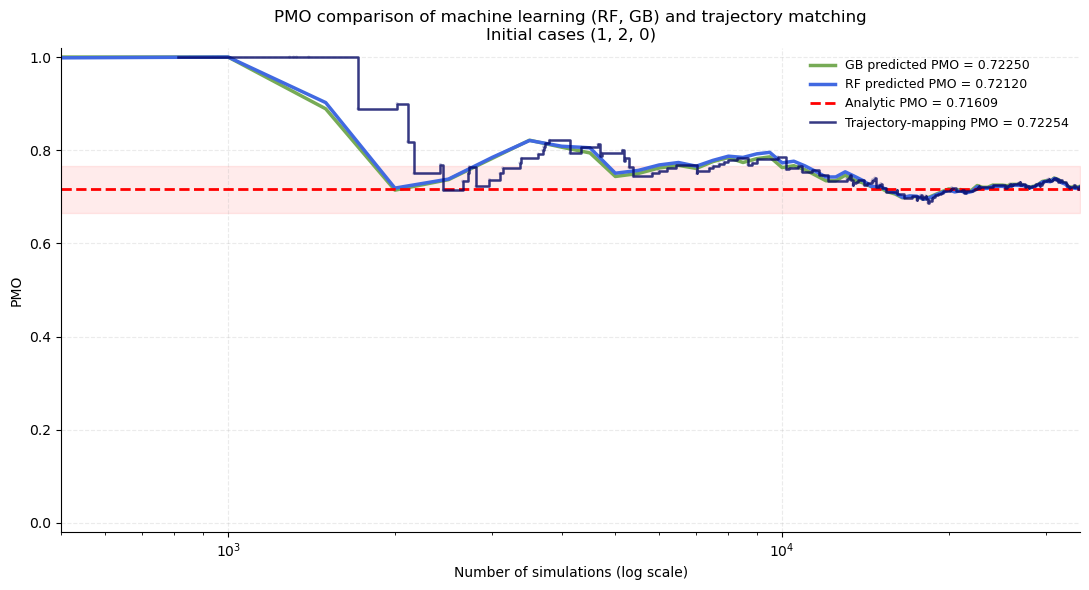

Saved plot: src/outbreak_probabilities/compare/comparison_initial_1_2_0.png | matches: 173 | analytic: 0.7160883829894712


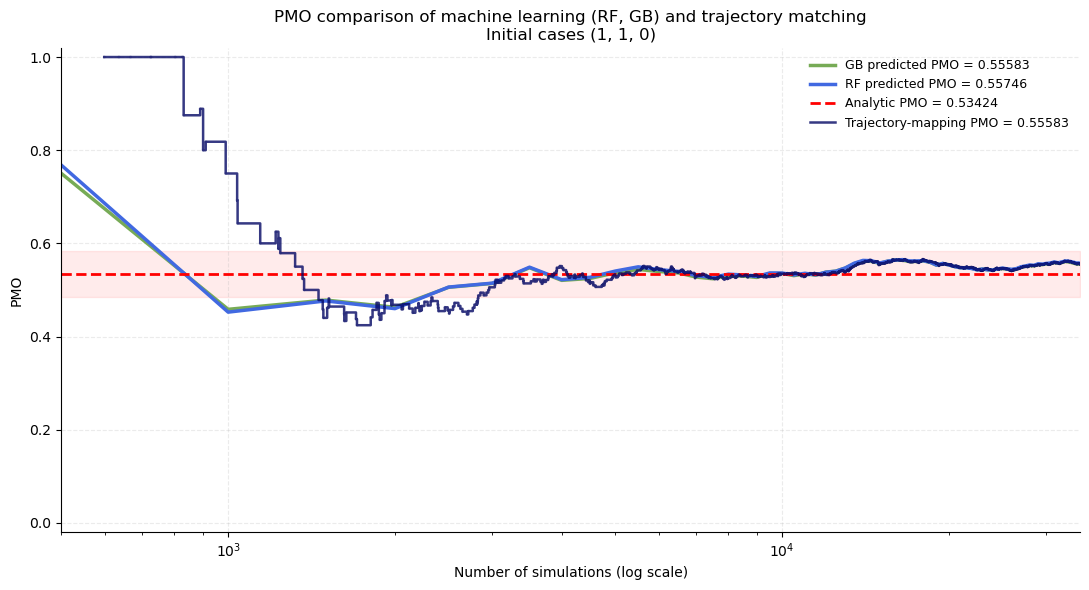

Saved plot: src/outbreak_probabilities/compare/comparison_initial_1_1_0.png | matches: 1236 | analytic: 0.534243856964009


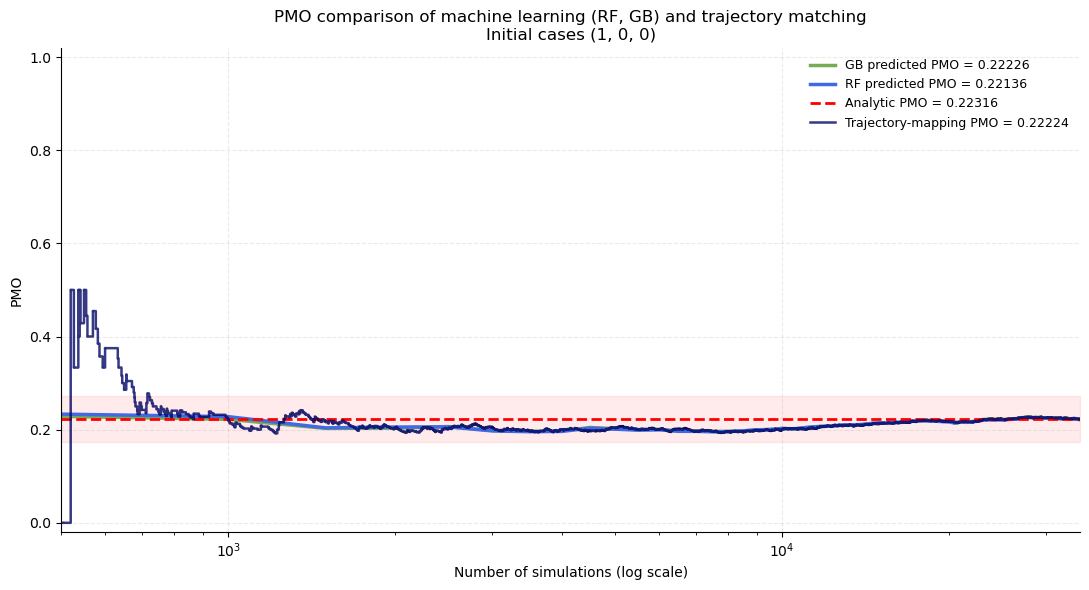

Saved plot: src/outbreak_probabilities/compare/comparison_initial_1_0_0.png | matches: 5296 | analytic: 0.2231625423613232


In [27]:
# ---- equivalent of: compare_combined.py __main__ ----
COMPARE_INITIALS = [(1, 2, 0), (1, 1, 0), (1, 0, 0)]

for INITIAL in COMPARE_INITIALS:
    make_combined_plot(
        initial_sample=INITIAL,
        sim_csv=SIM_OUT,
        model_dir=MODEL_SIM_DIR,
        data_sizes=data_sizes,
        model_names=["GB", "RF"],
        sample_size=None,  # include all matches up to each training size S
    )

## Summary

This notebook now reproduces the complete project pipeline end-to-end:

1. **Data generation** (`simulate`) - §1-4
2. **Trajectory / PMO-vs-R plots** (`plot`) - §5
3. **Analytic PMO estimator** (`analytic`) - §6
4. **Trajectory matching + matched plot** (`match`) - §7-8
5. **Cumulative PMO across matches** (`pmo_vs_r`) - §9
6. **ML convergence** (GB/RF training + plots) - §10
7. **Three-way comparison** (ML vs trajectory-matching vs analytic) - §11

All figures render inline and are also saved to disk (`figs/`, the
`machine_learning/.../ML_CONVERGENCE_PLOTS/` dirs, and
`src/outbreak_probabilities/compare/`).